## 📥 Stage 1 — Data Collection & Loading
> Import all required libraries and load the raw dataset for the first time.


In [213]:
# ── 1.1  Library Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold

# ── Global Style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"        : 110,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
})
print("✅ Libraries loaded.")


✅ Libraries loaded.


In [214]:
# ── 1.2  Load Dataset ─────────────────────────────────────────────────────────
df = pd.read_csv("/Users/himanshu/Downloads/SUL_project/diabetic_data.csv")

print(f"✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")


✅ Dataset loaded successfully!
   Rows    : 101,766
   Columns : 50


In [215]:
df_raw = df.copy()

---
## 🔎 Stage 2 — Data Understanding
> Inspect structure, data types, and summary statistics before any modification.


In [216]:
# ── 2.1  Shape & First Look ───────────────────────────────────────────────────
print(f"Dataset shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print()
df.head()


Dataset shape: 101,766 rows  ×  50 columns



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [217]:
# ── 2.2  Data Types & Non-Null Counts ────────────────────────────────────────
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [218]:
# ── 2.3  Descriptive Statistics (Numeric Columns) ────────────────────────────
df.describe()


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [219]:
df.replace("?", np.nan, inplace=True)
total_missing = df.isnull().sum().sum()

In [220]:

missing_before     = df.isnull().sum()
missing_pct_before = (missing_before / len(df)) * 100

missing_summary_before = pd.DataFrame({
    "Missing Count" : missing_before,
    "Missing (%)"   : missing_pct_before.round(2)
}).query("`Missing Count` > 0").sort_values("Missing (%)", ascending=False)

print("Missing Values — BEFORE Imputation:")
print(missing_summary_before.to_string())


Missing Values — BEFORE Imputation:
                   Missing Count  Missing (%)
weight                     98569        96.86
max_glu_serum              96420        94.75
A1Cresult                  84748        83.28
medical_specialty          49949        49.08
payer_code                 40256        39.56
race                        2273         2.23
diag_3                      1423         1.40
diag_2                       358         0.35
diag_1                        21         0.02


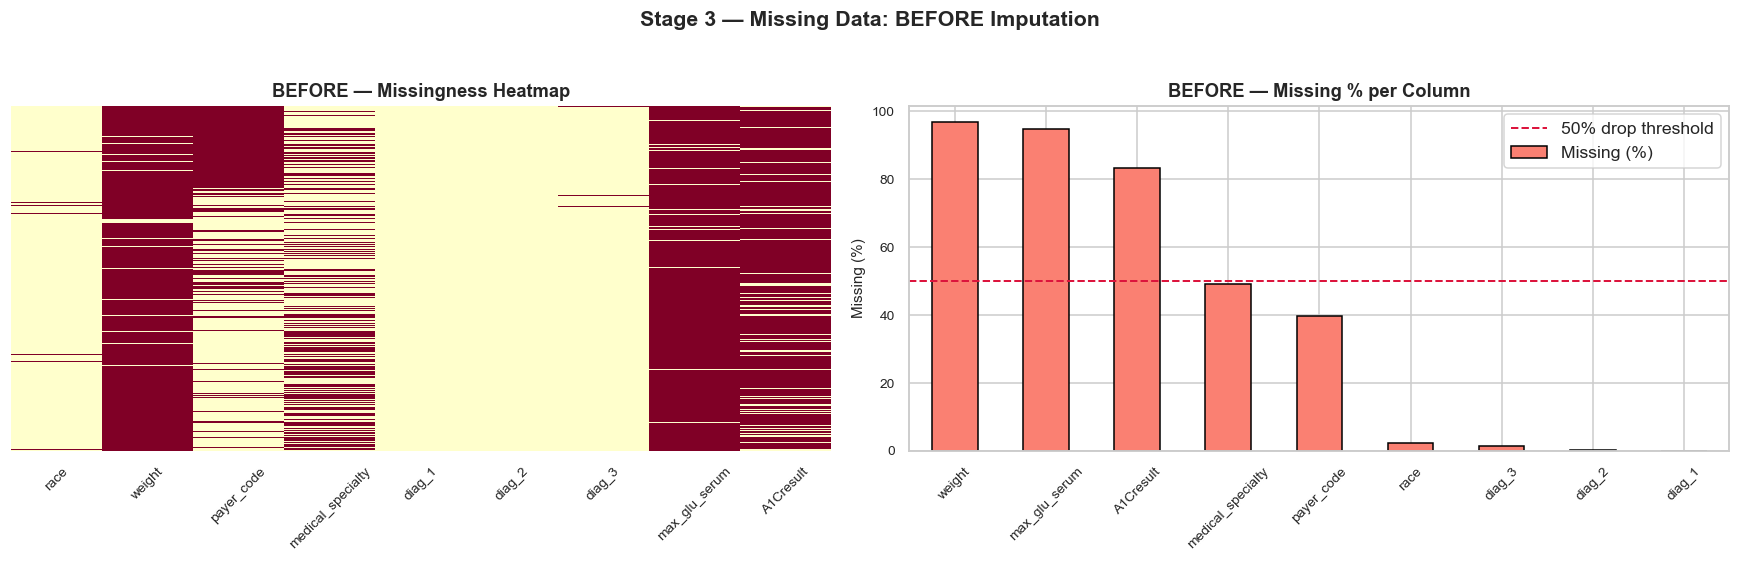

In [221]:
# ── 3.2  Visualise Missing Data — BEFORE ─────────────────────────────────────
cols_with_missing = missing_before[missing_before > 0].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Heatmap of missingness
sns.heatmap(df[cols_with_missing].isnull(), cbar=False, cmap="YlOrRd",
            yticklabels=False, ax=axes[0])
axes[0].set_title("BEFORE — Missingness Heatmap")
axes[0].tick_params(axis="x", rotation=45)

# Right: Missing % bar chart with 50% threshold line
missing_summary_before["Missing (%)"].plot(
    kind="bar", color="salmon", edgecolor="black", ax=axes[1])
axes[1].axhline(50, color="crimson", linestyle="--", linewidth=1.3, label="50% drop threshold")
axes[1].set_title("BEFORE — Missing % per Column")
axes[1].set_ylabel("Missing (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.suptitle("Stage 3 — Missing Data: BEFORE Imputation",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


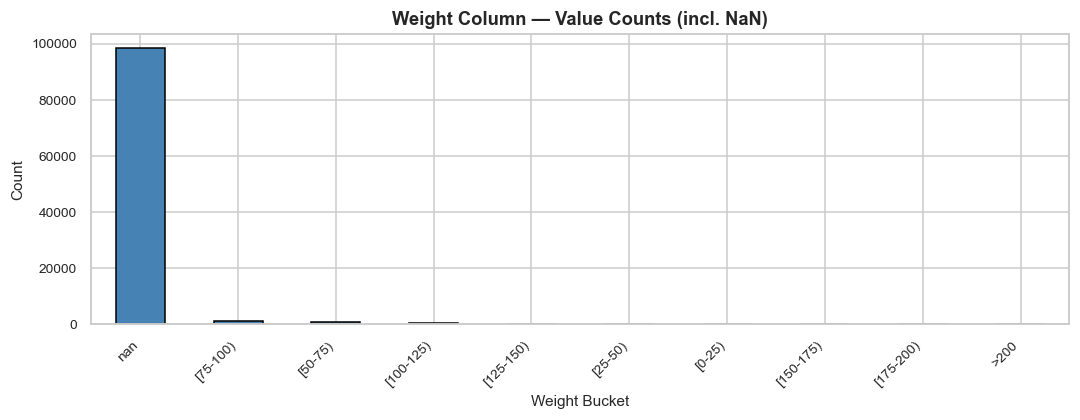

In [222]:
# ── 3.3  Weight Column — Value Distribution Before Drop ──────────────────────
# Shows why 'weight' cannot be meaningfully imputed (>96% missing).
if "weight" in df.columns:
    plt.figure(figsize=(10, 4))
    df["weight"].value_counts(dropna=False).head(15).plot(
        kind="bar", color="steelblue", edgecolor="black")
    plt.title("Weight Column — Value Counts (incl. NaN)", fontsize=12, fontweight="bold")
    plt.xlabel("Weight Bucket")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [223]:
# ── 3.4  Apply Imputation ─────────────────────────────────────────────────────

# Step A: Drop columns with > 50% missing
high_missing_cols = missing_summary_before[
    missing_summary_before["Missing (%)"] > 50].index.tolist()
df.drop(columns=high_missing_cols, inplace=True, errors="ignore")
print(f"Dropped (>50% missing): {high_missing_cols}")

# Step B: Mode fill for remaining categorical columns with nulls
for col in ["race", "payer_code", "medical_specialty"]:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  Mode-filled  '{col}'  →  '{mode_val}'")

# Step C: Fill diagnosis columns with 'Unknown' (preserves clinical ambiguity)
for col in ["diag_1", "diag_2", "diag_3"]:
    if col in df.columns:
        df[col].fillna("Unknown", inplace=True)
        print(f"  Unknown-filled  '{col}'")

print("✅ Imputation complete.")


Dropped (>50% missing): ['weight', 'max_glu_serum', 'A1Cresult']
  Mode-filled  'race'  →  'Caucasian'
  Mode-filled  'payer_code'  →  'MC'
  Mode-filled  'medical_specialty'  →  'InternalMedicine'
  Unknown-filled  'diag_1'
  Unknown-filled  'diag_2'
  Unknown-filled  'diag_3'
✅ Imputation complete.


/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_15490/3108068046.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)
/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_15490/3108068046.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [224]:
# ── Step D: KNN Imputation for Numeric Columns ──────────────────────────

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Select numeric columns only
num_cols = df.select_dtypes(include=np.number).columns

# Scale data (IMPORTANT for KNN)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[num_cols])

# Apply KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)
imputed_data = knn_imputer.fit_transform(scaled_data)

# Convert back to original scale
df[num_cols] = scaler.inverse_transform(imputed_data)

print("  ✅ KNN Imputation applied on numeric columns")

  ✅ KNN Imputation applied on numeric columns


In [225]:
# ── 3.5  Confirm — Zero Missing Values After Imputation ──────────────────────
missing_after = df.isnull().sum()
still_missing = missing_after[missing_after > 0]

if still_missing.empty:
    print("✅ Zero missing values remaining in the dataset!")
else:
    print("⚠️  Columns still missing:")
    print(still_missing)


✅ Zero missing values remaining in the dataset!


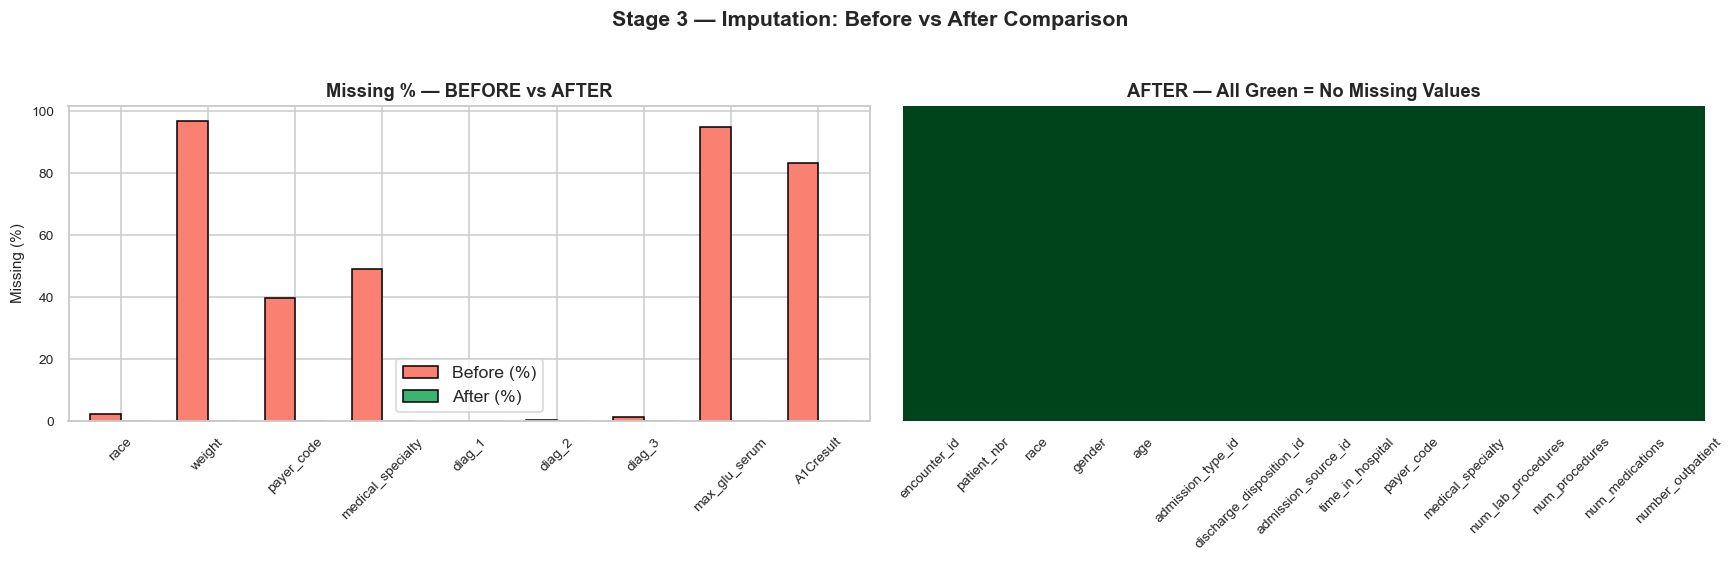

In [226]:
# ── 3.6  Before vs After — Side-by-Side Comparison ───────────────────────────
compared_cols        = missing_before[missing_before > 0].index.tolist()
compared_cols_present = [c for c in compared_cols if c in df.columns]
after_pct            = df[compared_cols_present].isnull().sum() / len(df) * 100

comparison_df = pd.DataFrame({
    "Before (%)": missing_pct_before[compared_cols],
    "After (%)" : [after_pct.get(c, 0) for c in compared_cols]
}, index=compared_cols)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar chart
comparison_df.plot(kind="bar", color=["salmon", "mediumseagreen"],
                   edgecolor="black", width=0.7, ax=axes[0])
axes[0].set_title("Missing % — BEFORE vs AFTER")
axes[0].set_ylabel("Missing (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Right: clean heatmap after imputation
sample_cols = df.columns[:15].tolist()
sns.heatmap(df[sample_cols].isnull(), cbar=False, cmap="Greens_r",
            yticklabels=False, ax=axes[1])
axes[1].set_title("AFTER — All Green = No Missing Values")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Stage 3 — Imputation: Before vs After Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


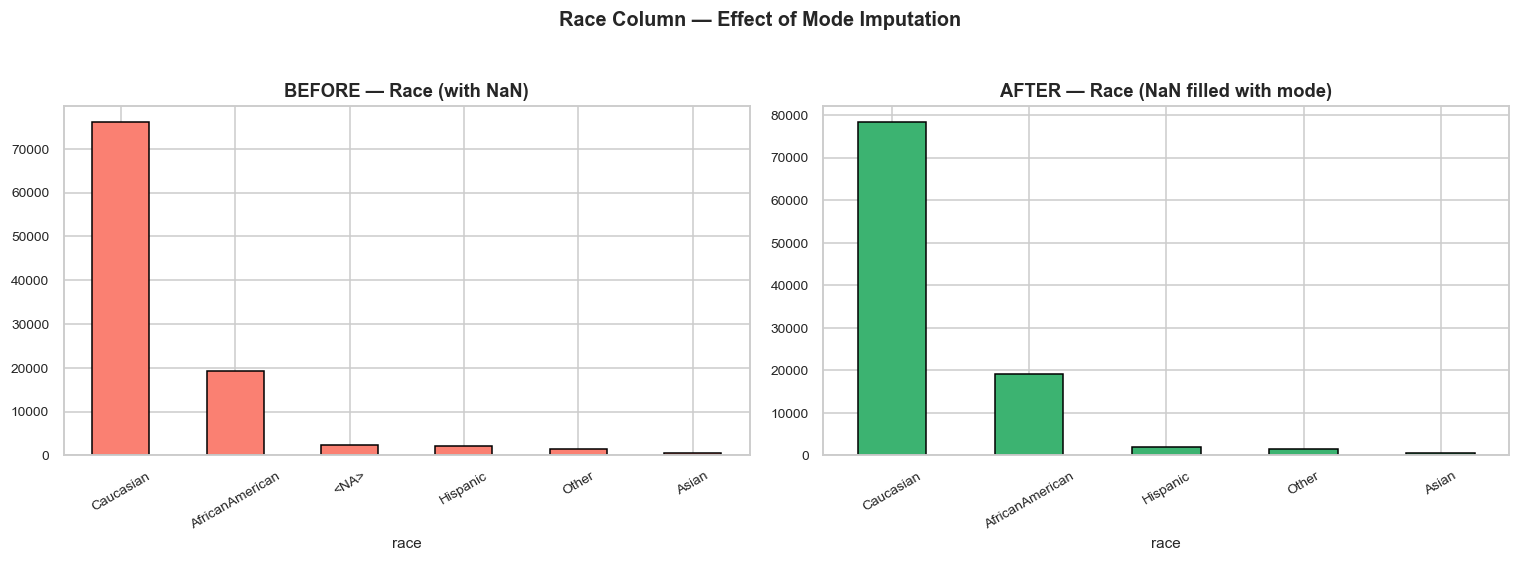

In [227]:
# ── 3.7  Race Column — Before vs After Mode Imputation ───────────────────────
if "race" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Reload original race column for 'before' view
    orig = pd.read_csv("/Users/himanshu/Downloads/SUL_project/diabetic_data.csv",
                       usecols=["race"])
    orig.replace("?", pd.NA, inplace=True)

    orig["race"].value_counts(dropna=False).plot(
        kind="bar", color="salmon", edgecolor="black", ax=axes[0])
    axes[0].set_title("BEFORE — Race (with NaN)")
    axes[0].tick_params(axis="x", rotation=30)

    df["race"].value_counts(dropna=False).plot(
        kind="bar", color="mediumseagreen", edgecolor="black", ax=axes[1])
    axes[1].set_title("AFTER — Race (NaN filled with mode)")
    axes[1].tick_params(axis="x", rotation=30)

    plt.suptitle("Race Column — Effect of Mode Imputation",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


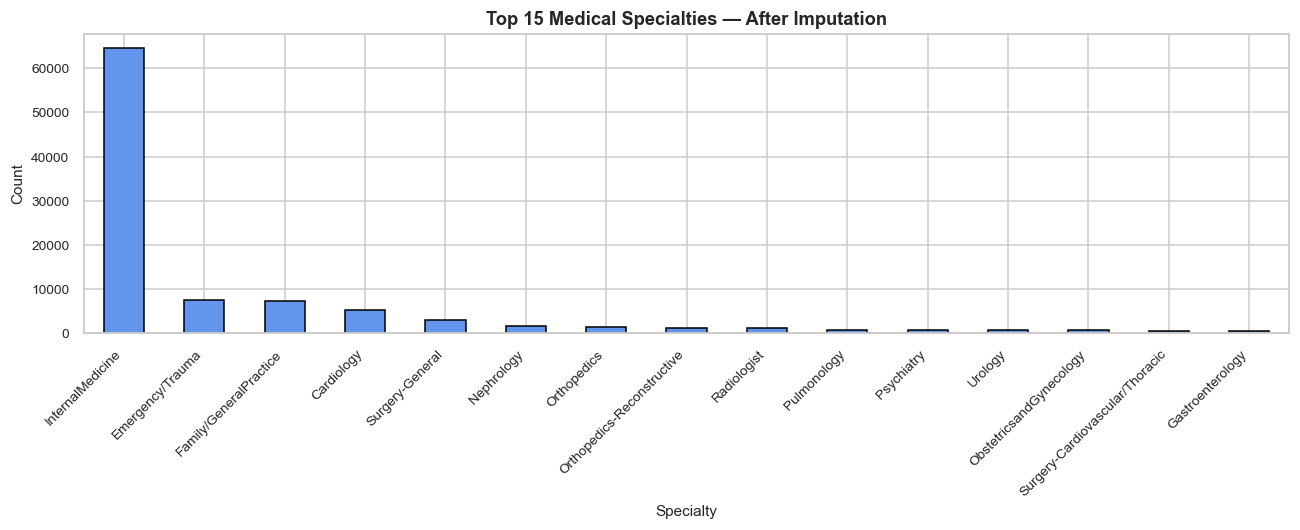

In [228]:
# ── 3.8  Medical Specialty — Post-Imputation Top 15 ──────────────────────────
if "medical_specialty" in df.columns:
    plt.figure(figsize=(12, 5))
    df["medical_specialty"].value_counts().head(15).plot(
        kind="bar", color="cornflowerblue", edgecolor="black")
    plt.title("Top 15 Medical Specialties — After Imputation",
              fontsize=12, fontweight="bold")
    plt.xlabel("Specialty")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


---
## ⚙️ Encoding — Convert Categoricals to Numeric
> All categorical columns must be encoded before numeric analysis and modelling.
> This is a prerequisite for Stages 4–8.


In [229]:
# ── Encoding: Binary, Ordinal, and Remaining Categoricals ────────────────────
le = LabelEncoder()

# Binary columns (2 unique values)
for col in ["gender", "change", "diabetesMed"]:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# Ordinal medication dosage columns
med_mapping = {"No": 0, "Steady": 1, "Up": 2, "Down": 3}
med_cols = [
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride",
    "acetohexamide","glipizide","glyburide","tolbutamide","pioglitazone",
    "rosiglitazone","acarbose","miglitol","troglitazone","tolazamide",
    "examide","citoglipton","insulin","glyburide-metformin",
    "glipizide-metformin","glimepiride-pioglitazone",
    "metformin-rosiglitazone","metformin-pioglitazone"
]
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_mapping)

# All remaining object columns (label encode)
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

print("✅ Encoding complete.")
print(f"   Numeric columns : {df.select_dtypes(include='number').shape[1]}")
print(f"   Object columns  : {df.select_dtypes(include='object').shape[1]}")


✅ Encoding complete.
   Numeric columns : 47
   Object columns  : 0


In [230]:
df_clean = df.copy()

---
## 📊 Stage 4 — Univariate Analysis
> Examine each variable in isolation. Understand distributions, skewness, and class balance.


/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_15490/80785768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="readmitted", data=df, palette="Set2", ax=axes[0])


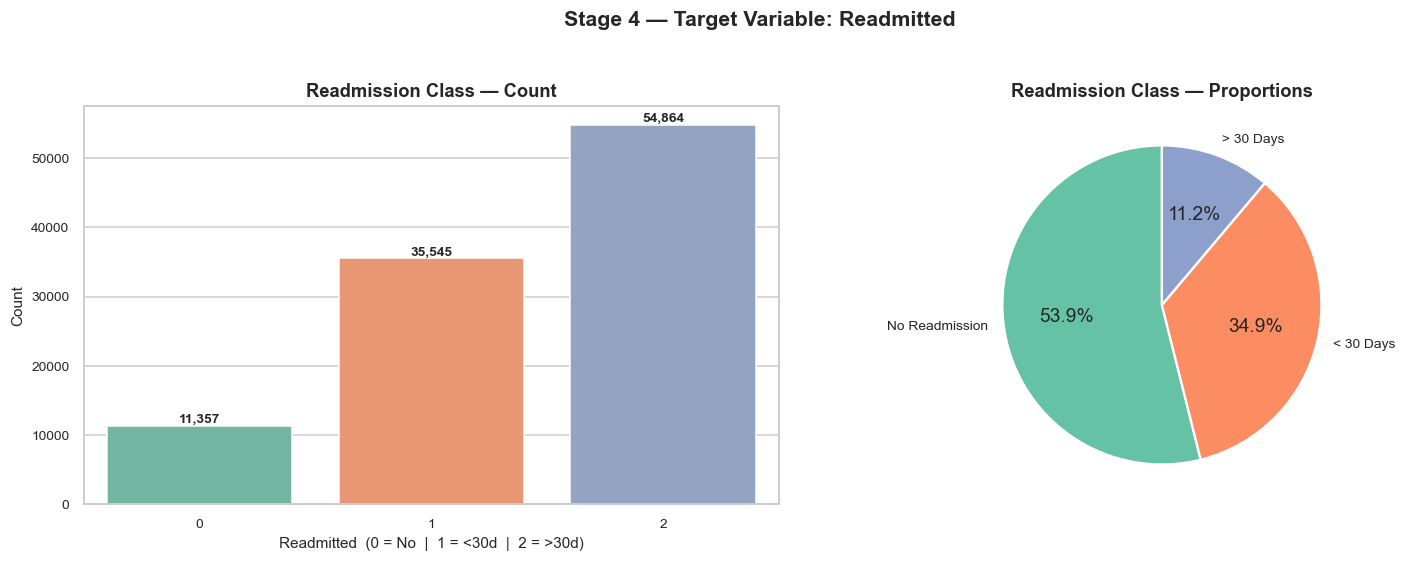

In [231]:
# ── 4.1  Target Variable — Readmission Distribution ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot with value labels
ax = sns.countplot(x="readmitted", data=df, palette="Set2", ax=axes[0])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Readmission Class — Count")
axes[0].set_xlabel("Readmitted  (0 = No  |  1 = <30d  |  2 = >30d)")
axes[0].set_ylabel("Count")

# Pie chart
df["readmitted"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62", "#8da0cb"],
    labels=["No Readmission", "< 30 Days", "> 30 Days"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_ylabel("")
axes[1].set_title("Readmission Class — Proportions")

plt.suptitle("Stage 4 — Target Variable: Readmitted",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_15490/3665920965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="age", data=df, palette="Blues_d")


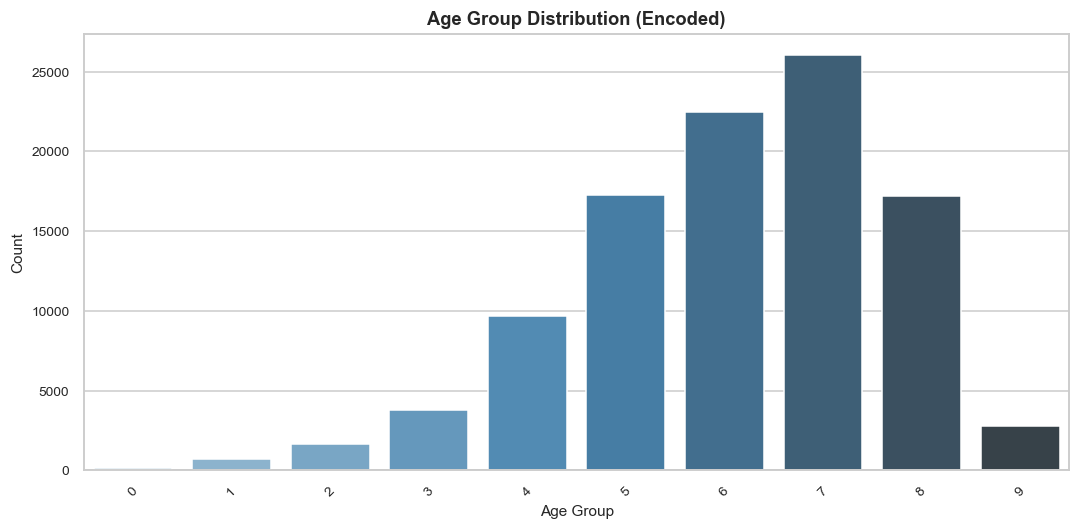

In [232]:
# ── 4.2  Age Group Distribution ───────────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.countplot(x="age", data=df, palette="Blues_d")
plt.title("Age Group Distribution (Encoded)", fontsize=12, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


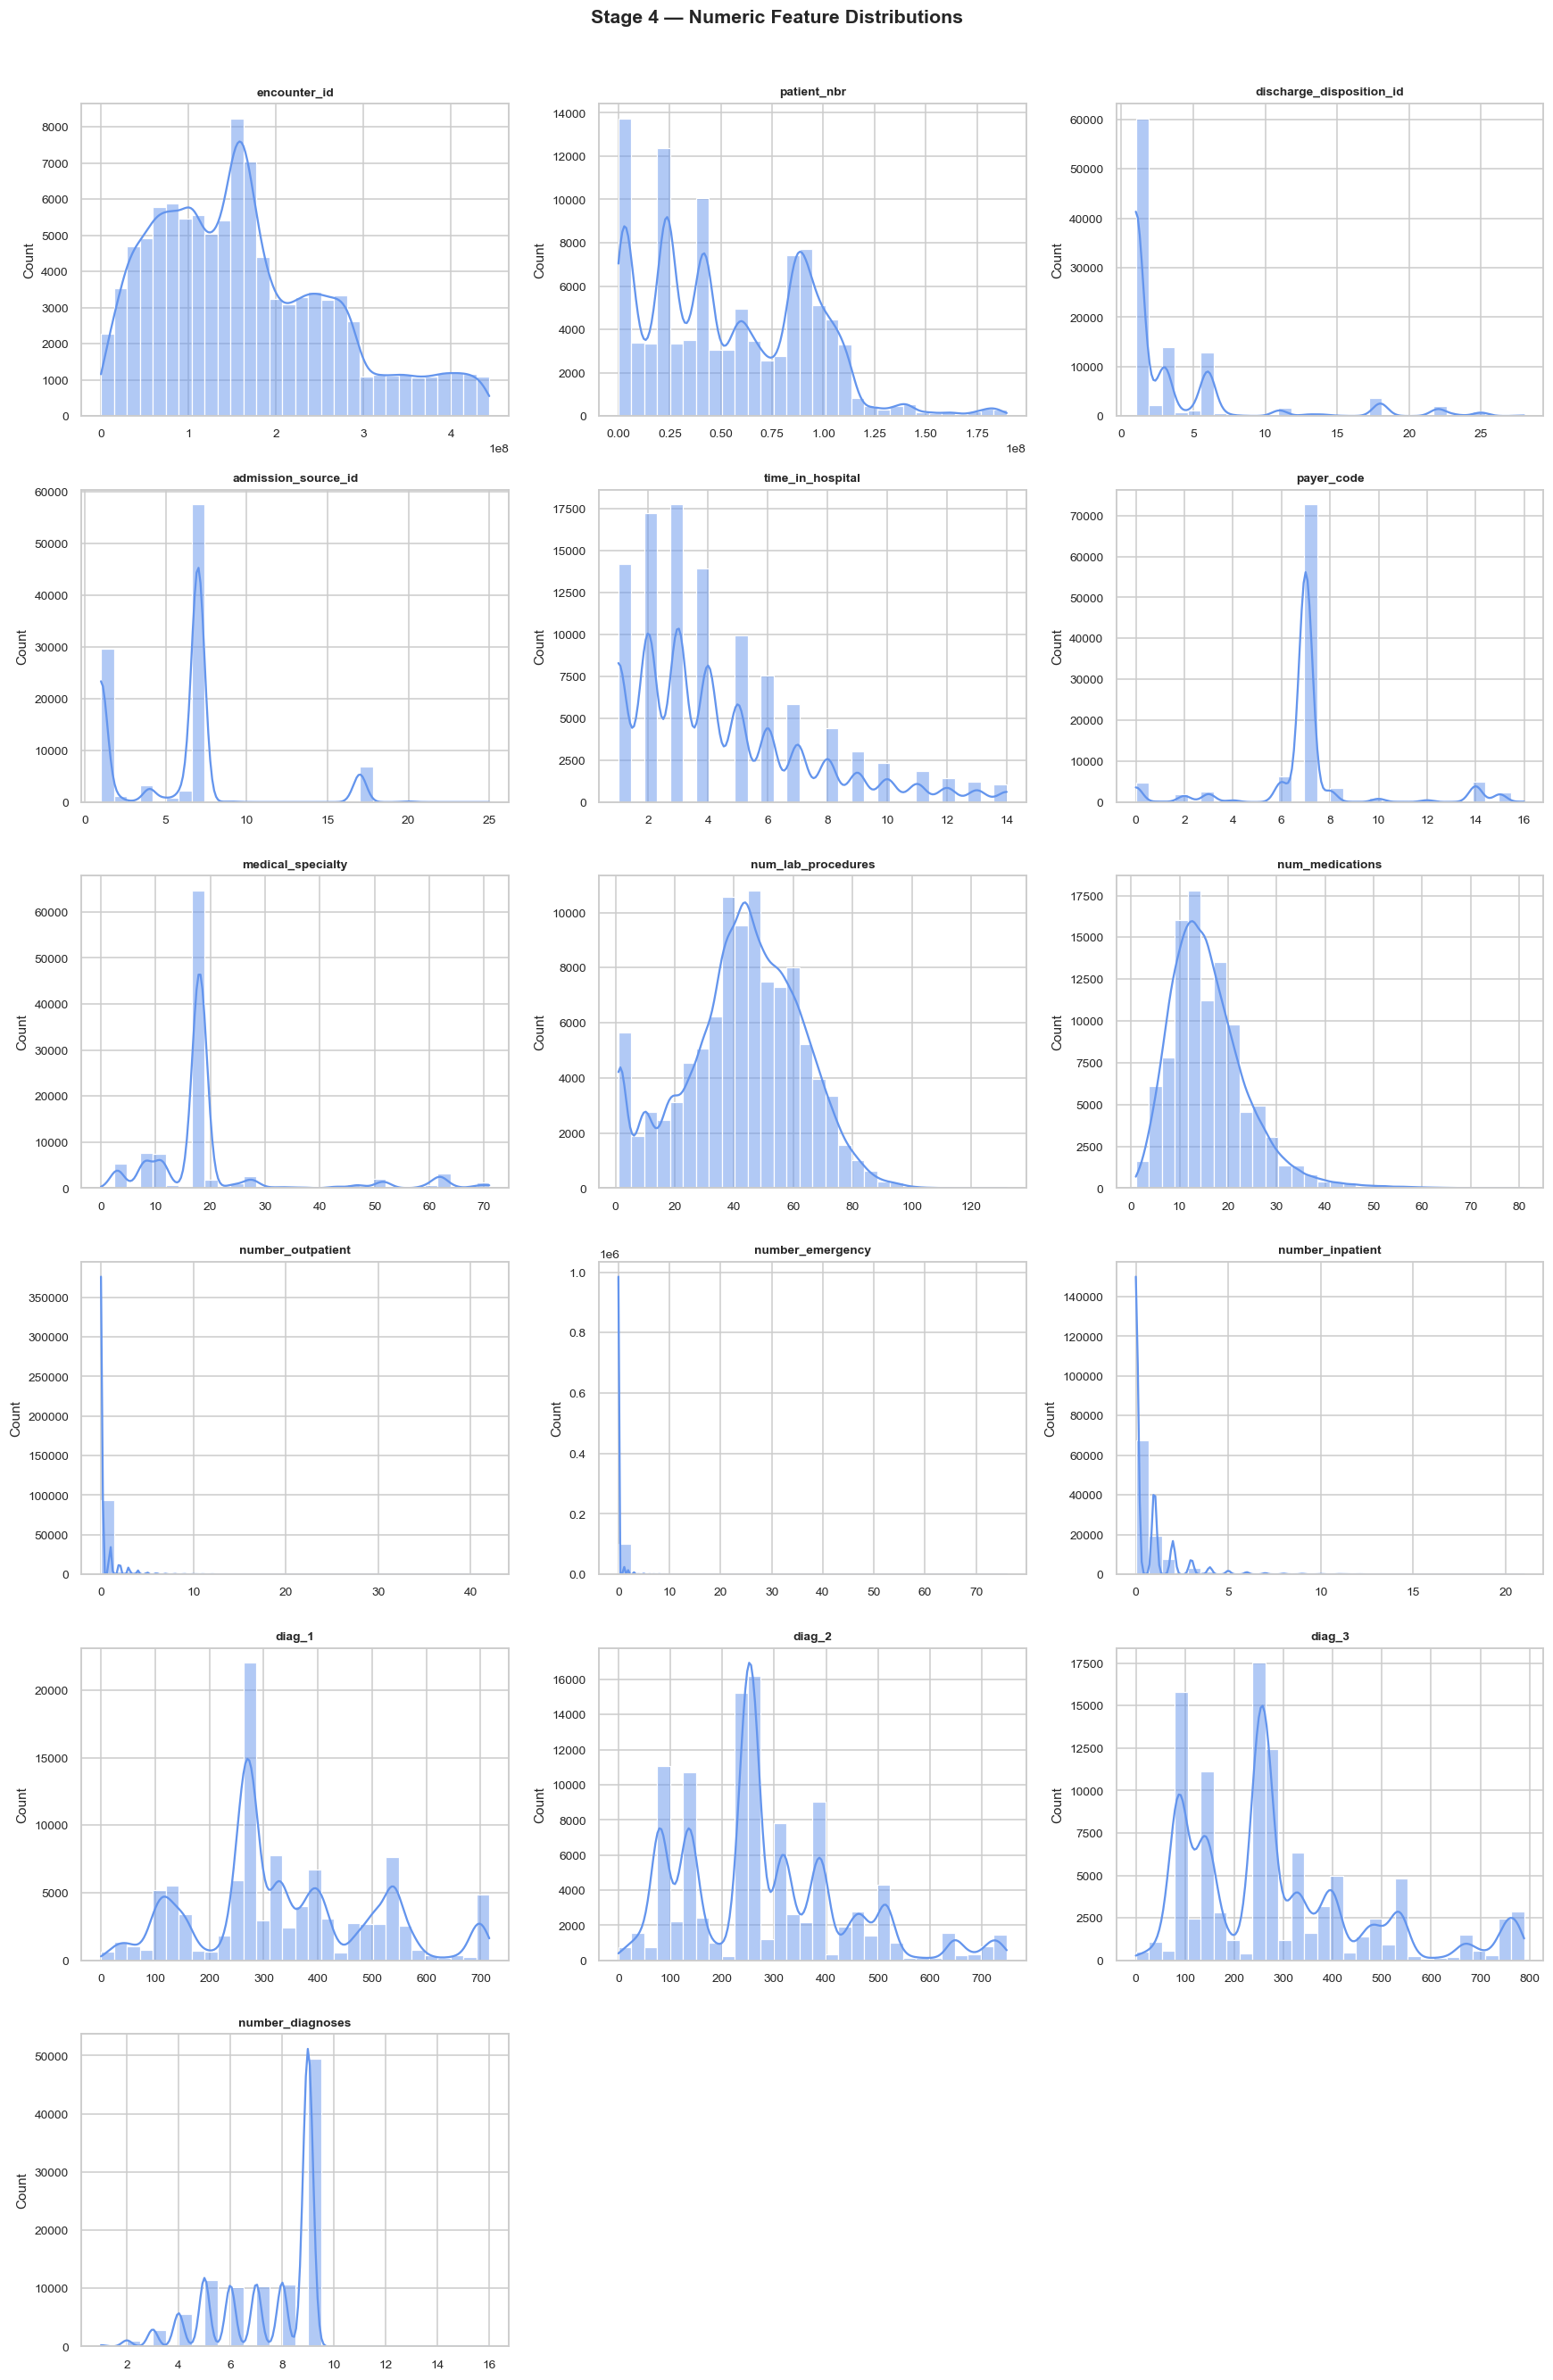

In [233]:
# ── 4.3  Numeric Feature Distributions — Histograms ──────────────────────────
num_cols    = df.select_dtypes(include=["int64","float64"]).columns.tolist()
key_numeric = [c for c in num_cols if df[c].nunique() > 10 and c != "readmitted"]

n            = len(key_numeric)
cols_per_row = 3
rows         = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes      = axes.flatten()

for i, col in enumerate(key_numeric):
    sns.histplot(df[col], kde=True, ax=axes[i],
                 color="cornflowerblue", edgecolor="white", bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Stage 4 — Numeric Feature Distributions",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


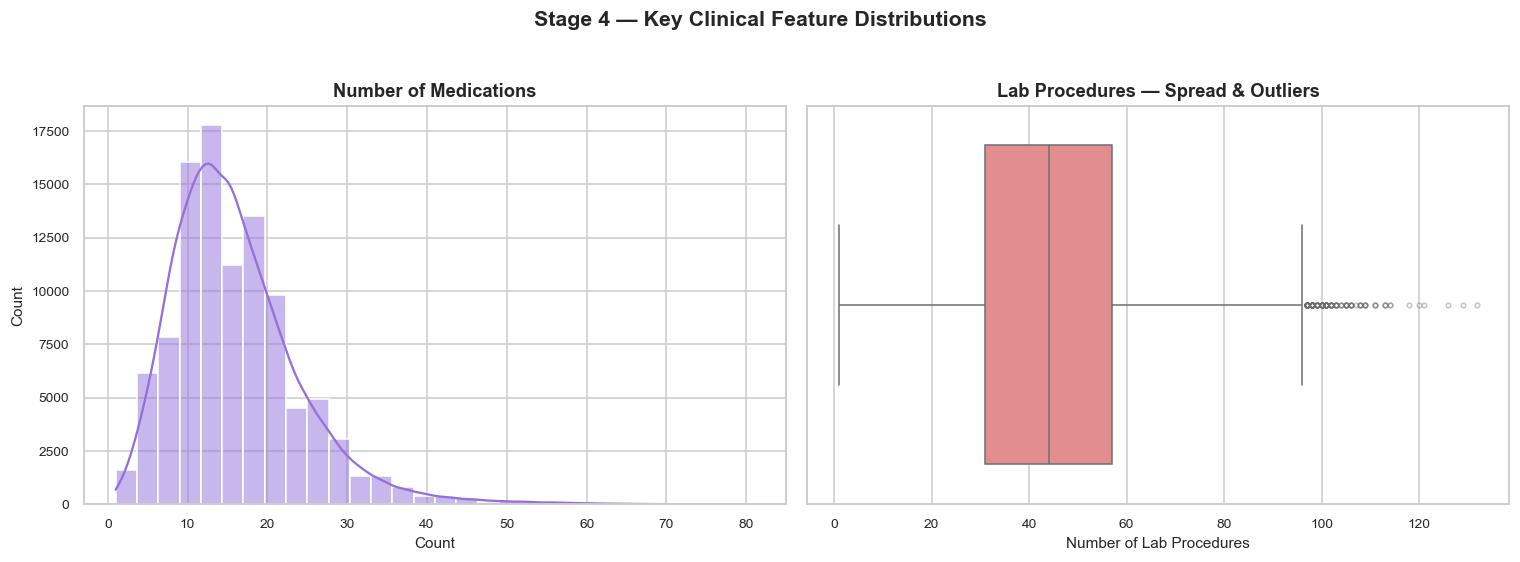

In [234]:
# ── 4.4  Key Clinical Columns — Detailed View ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["num_medications"], kde=True, ax=axes[0],
             color="mediumpurple", bins=30)
axes[0].set_title("Number of Medications")
axes[0].set_xlabel("Count")

sns.boxplot(x=df["num_lab_procedures"], ax=axes[1], color="lightcoral",
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
axes[1].set_title("Lab Procedures — Spread & Outliers")
axes[1].set_xlabel("Number of Lab Procedures")

plt.suptitle("Stage 4 — Key Clinical Feature Distributions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 🔗 Stage 5 — Bivariate Analysis
> Explore relationships between pairs of variables — primarily each feature against the target `readmitted`.


/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_15490/1220119684.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="readmitted", y="time_in_hospital", data=df,
/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_15490/1220119684.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="readmitted", y="num_medications", data=df,


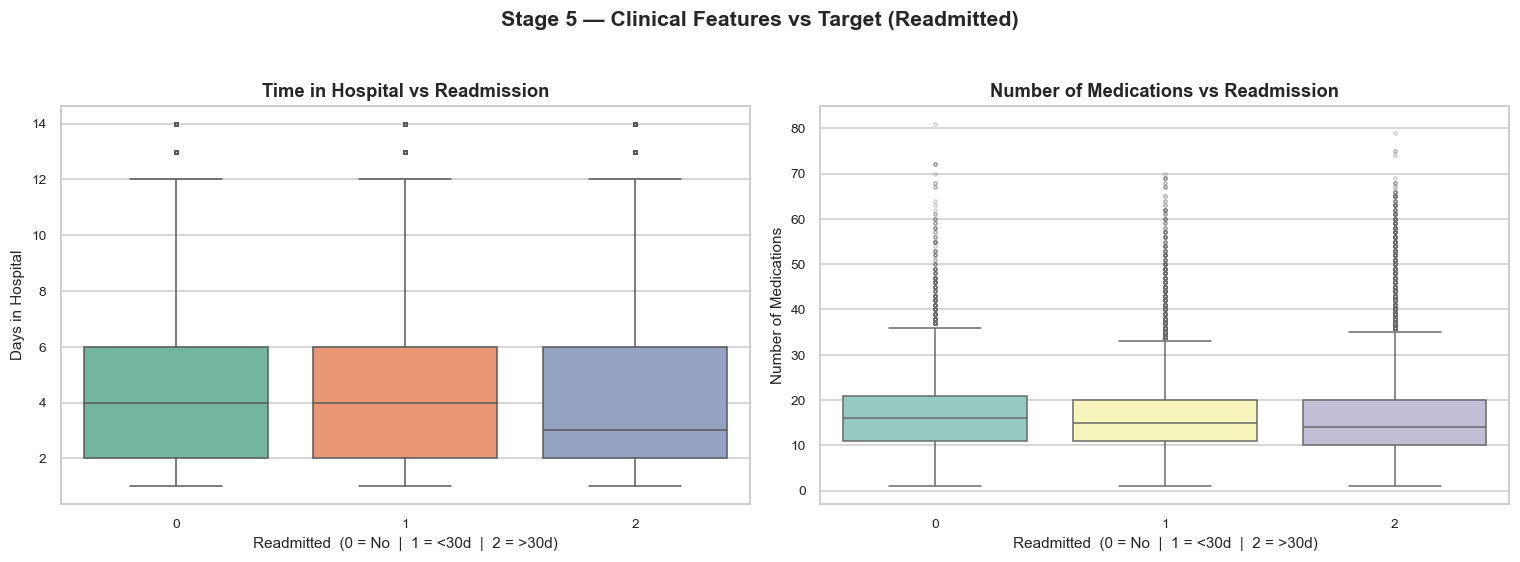

In [235]:
# ── 5.1  Hospital Stay & Medications vs Readmission ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="readmitted", y="time_in_hospital", data=df,
            palette="Set2", ax=axes[0],
            flierprops=dict(marker="o", markersize=2, alpha=0.3))
axes[0].set_title("Time in Hospital vs Readmission")
axes[0].set_xlabel("Readmitted  (0 = No  |  1 = <30d  |  2 = >30d)")
axes[0].set_ylabel("Days in Hospital")

sns.boxplot(x="readmitted", y="num_medications", data=df,
            palette="Set3", ax=axes[1],
            flierprops=dict(marker="o", markersize=2, alpha=0.3))
axes[1].set_title("Number of Medications vs Readmission")
axes[1].set_xlabel("Readmitted  (0 = No  |  1 = <30d  |  2 = >30d)")
axes[1].set_ylabel("Number of Medications")

plt.suptitle("Stage 5 — Clinical Features vs Target (Readmitted)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


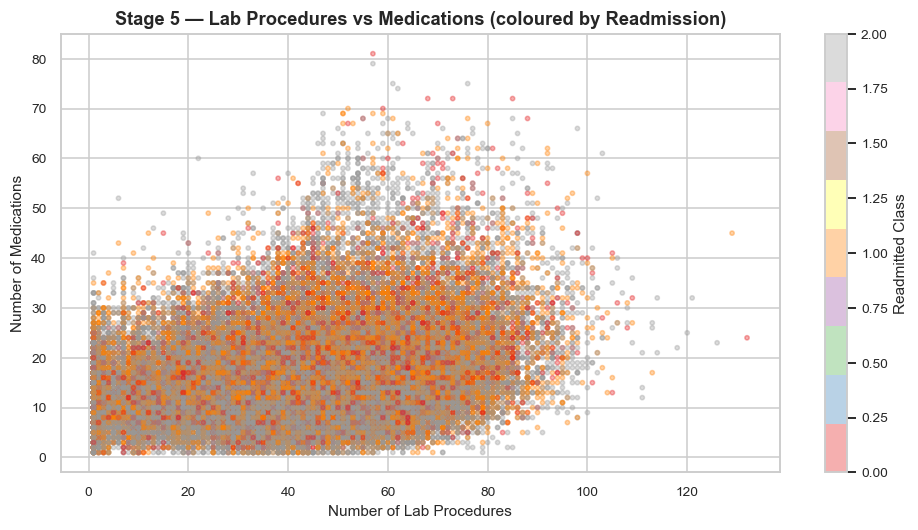

In [236]:
# ── 5.2  Lab Procedures vs Medications (Scatter coloured by Readmission) ─────
plt.figure(figsize=(9, 5))
sc = plt.scatter(df["num_lab_procedures"], df["num_medications"],
                 c=df["readmitted"], cmap="Set1", alpha=0.35, s=8)
plt.colorbar(sc, label="Readmitted Class")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Number of Medications")
plt.title("Stage 5 — Lab Procedures vs Medications (coloured by Readmission)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 🧩 Stage 6 — Multivariate Analysis
> Analyse interactions among three or more variables using correlation heatmaps and pairplots.


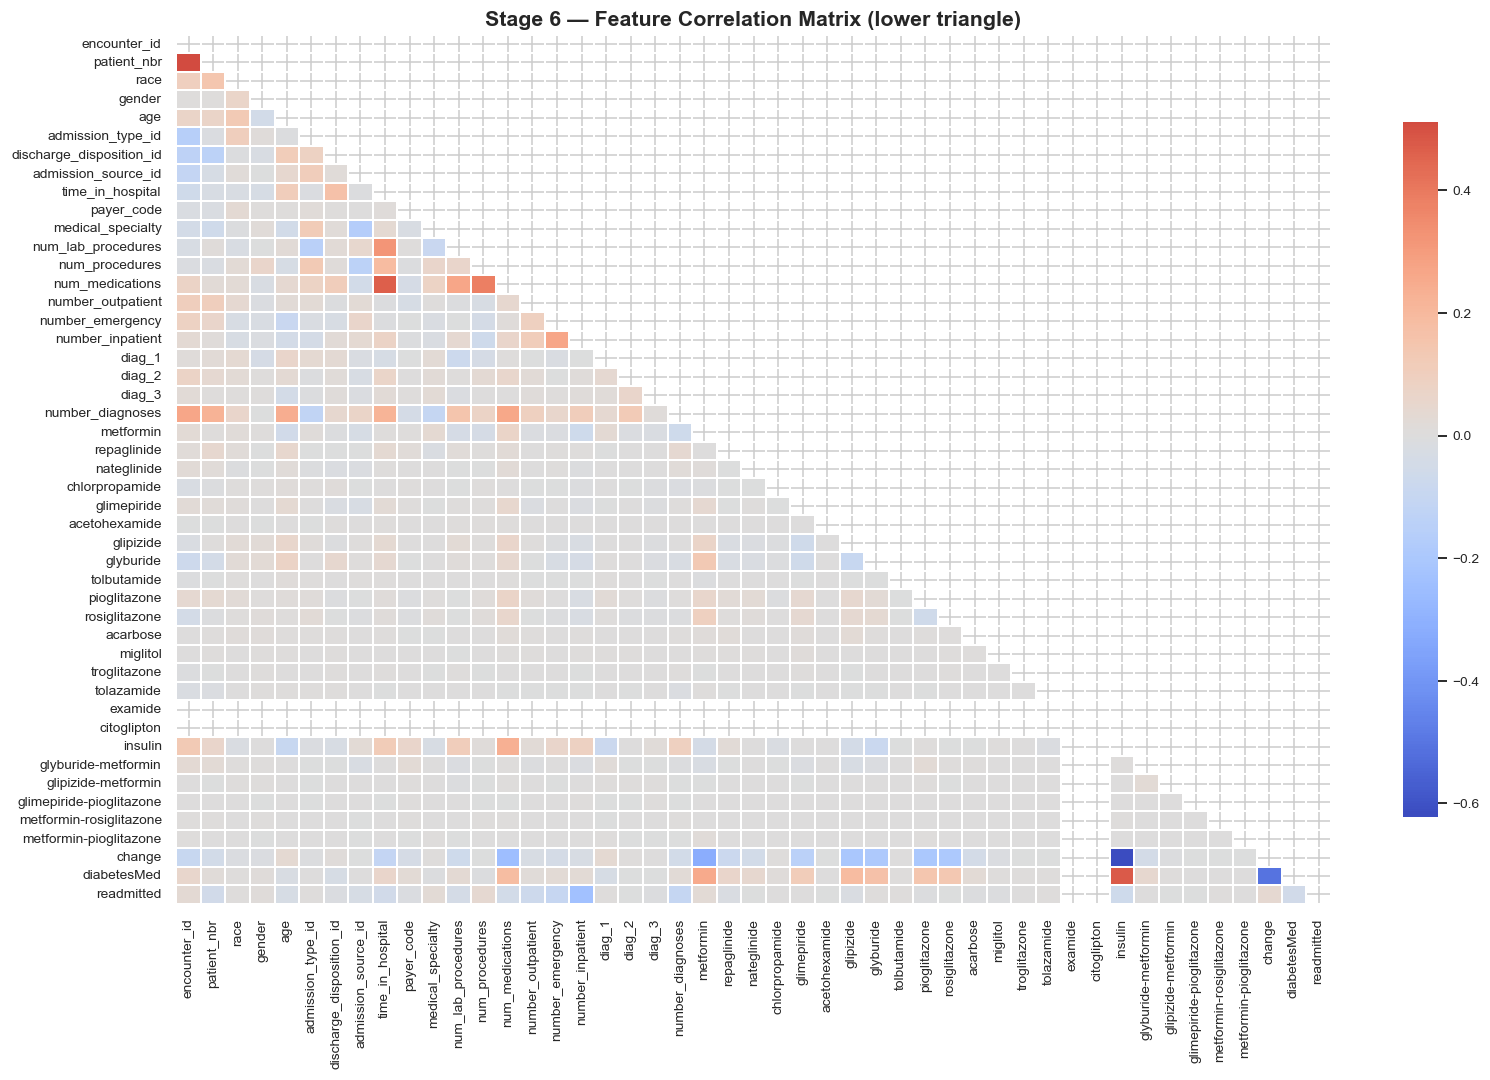

In [237]:
# ── 6.1  Correlation Heatmap (Lower Triangle) ─────────────────────────────────
numeric_df = df.select_dtypes(include=["int64","float64"])
corr       = numeric_df.corr()
mask       = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

plt.figure(figsize=(15, 10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.3, annot=False, square=False, cbar_kws={"shrink": 0.8})
plt.title("Stage 6 — Feature Correlation Matrix (lower triangle)",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


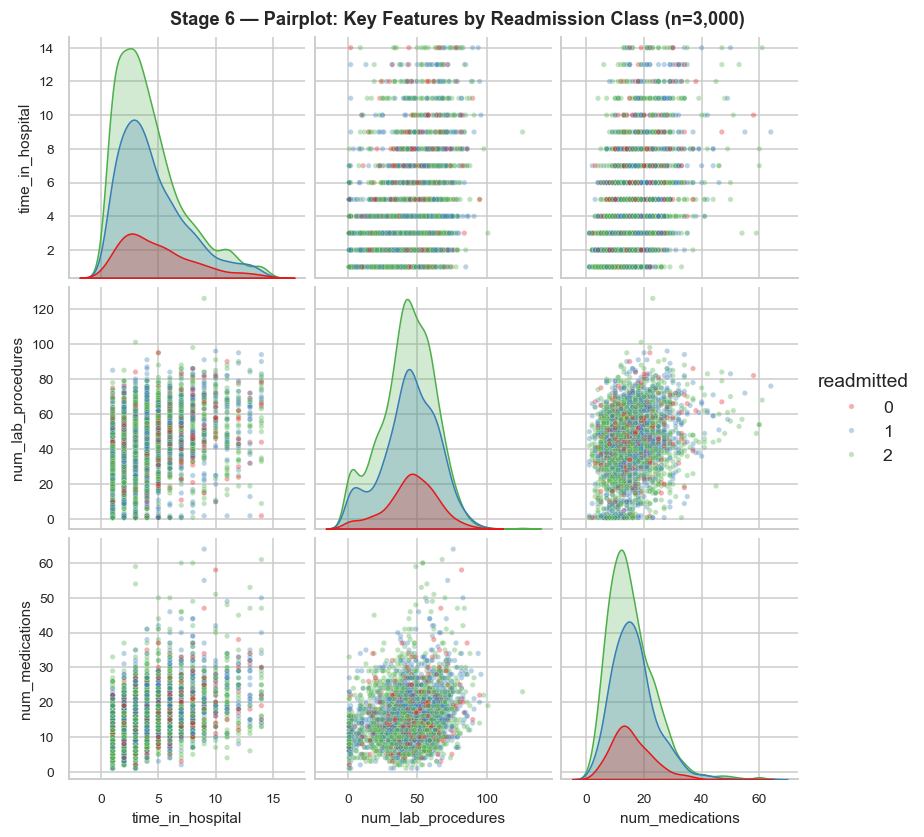

In [238]:
# ── 6.2  Pairplot — Key Features vs Readmission ───────────────────────────────
# Sampled to 3,000 rows for performance
sample_df = df[["time_in_hospital","num_lab_procedures",
                "num_medications","readmitted"]].sample(3000, random_state=42)

g = sns.pairplot(sample_df, hue="readmitted", palette="Set1",
                 plot_kws={"alpha": 0.35, "s": 12},
                 diag_kind="kde")
g.figure.suptitle("Stage 6 — Pairplot: Key Features by Readmission Class (n=3,000)",
                   fontsize=12, fontweight="bold", y=1.01)
plt.show()


In [239]:
# ── 7.1  Select Continuous Columns for Outlier Analysis ──────────────────────
# Skip binary/flag columns (nunique <= 10) and the target.
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
key_numeric  = [c for c in numeric_cols
                if df[c].nunique() > 10 and c != "readmitted"]

print(f"Columns selected for outlier analysis ({len(key_numeric)} total):")
for c in key_numeric:
    print(f"  • {c}")


Columns selected for outlier analysis (16 total):
  • encounter_id
  • patient_nbr
  • discharge_disposition_id
  • admission_source_id
  • time_in_hospital
  • payer_code
  • medical_specialty
  • num_lab_procedures
  • num_medications
  • number_outpatient
  • number_emergency
  • number_inpatient
  • diag_1
  • diag_2
  • diag_3
  • number_diagnoses


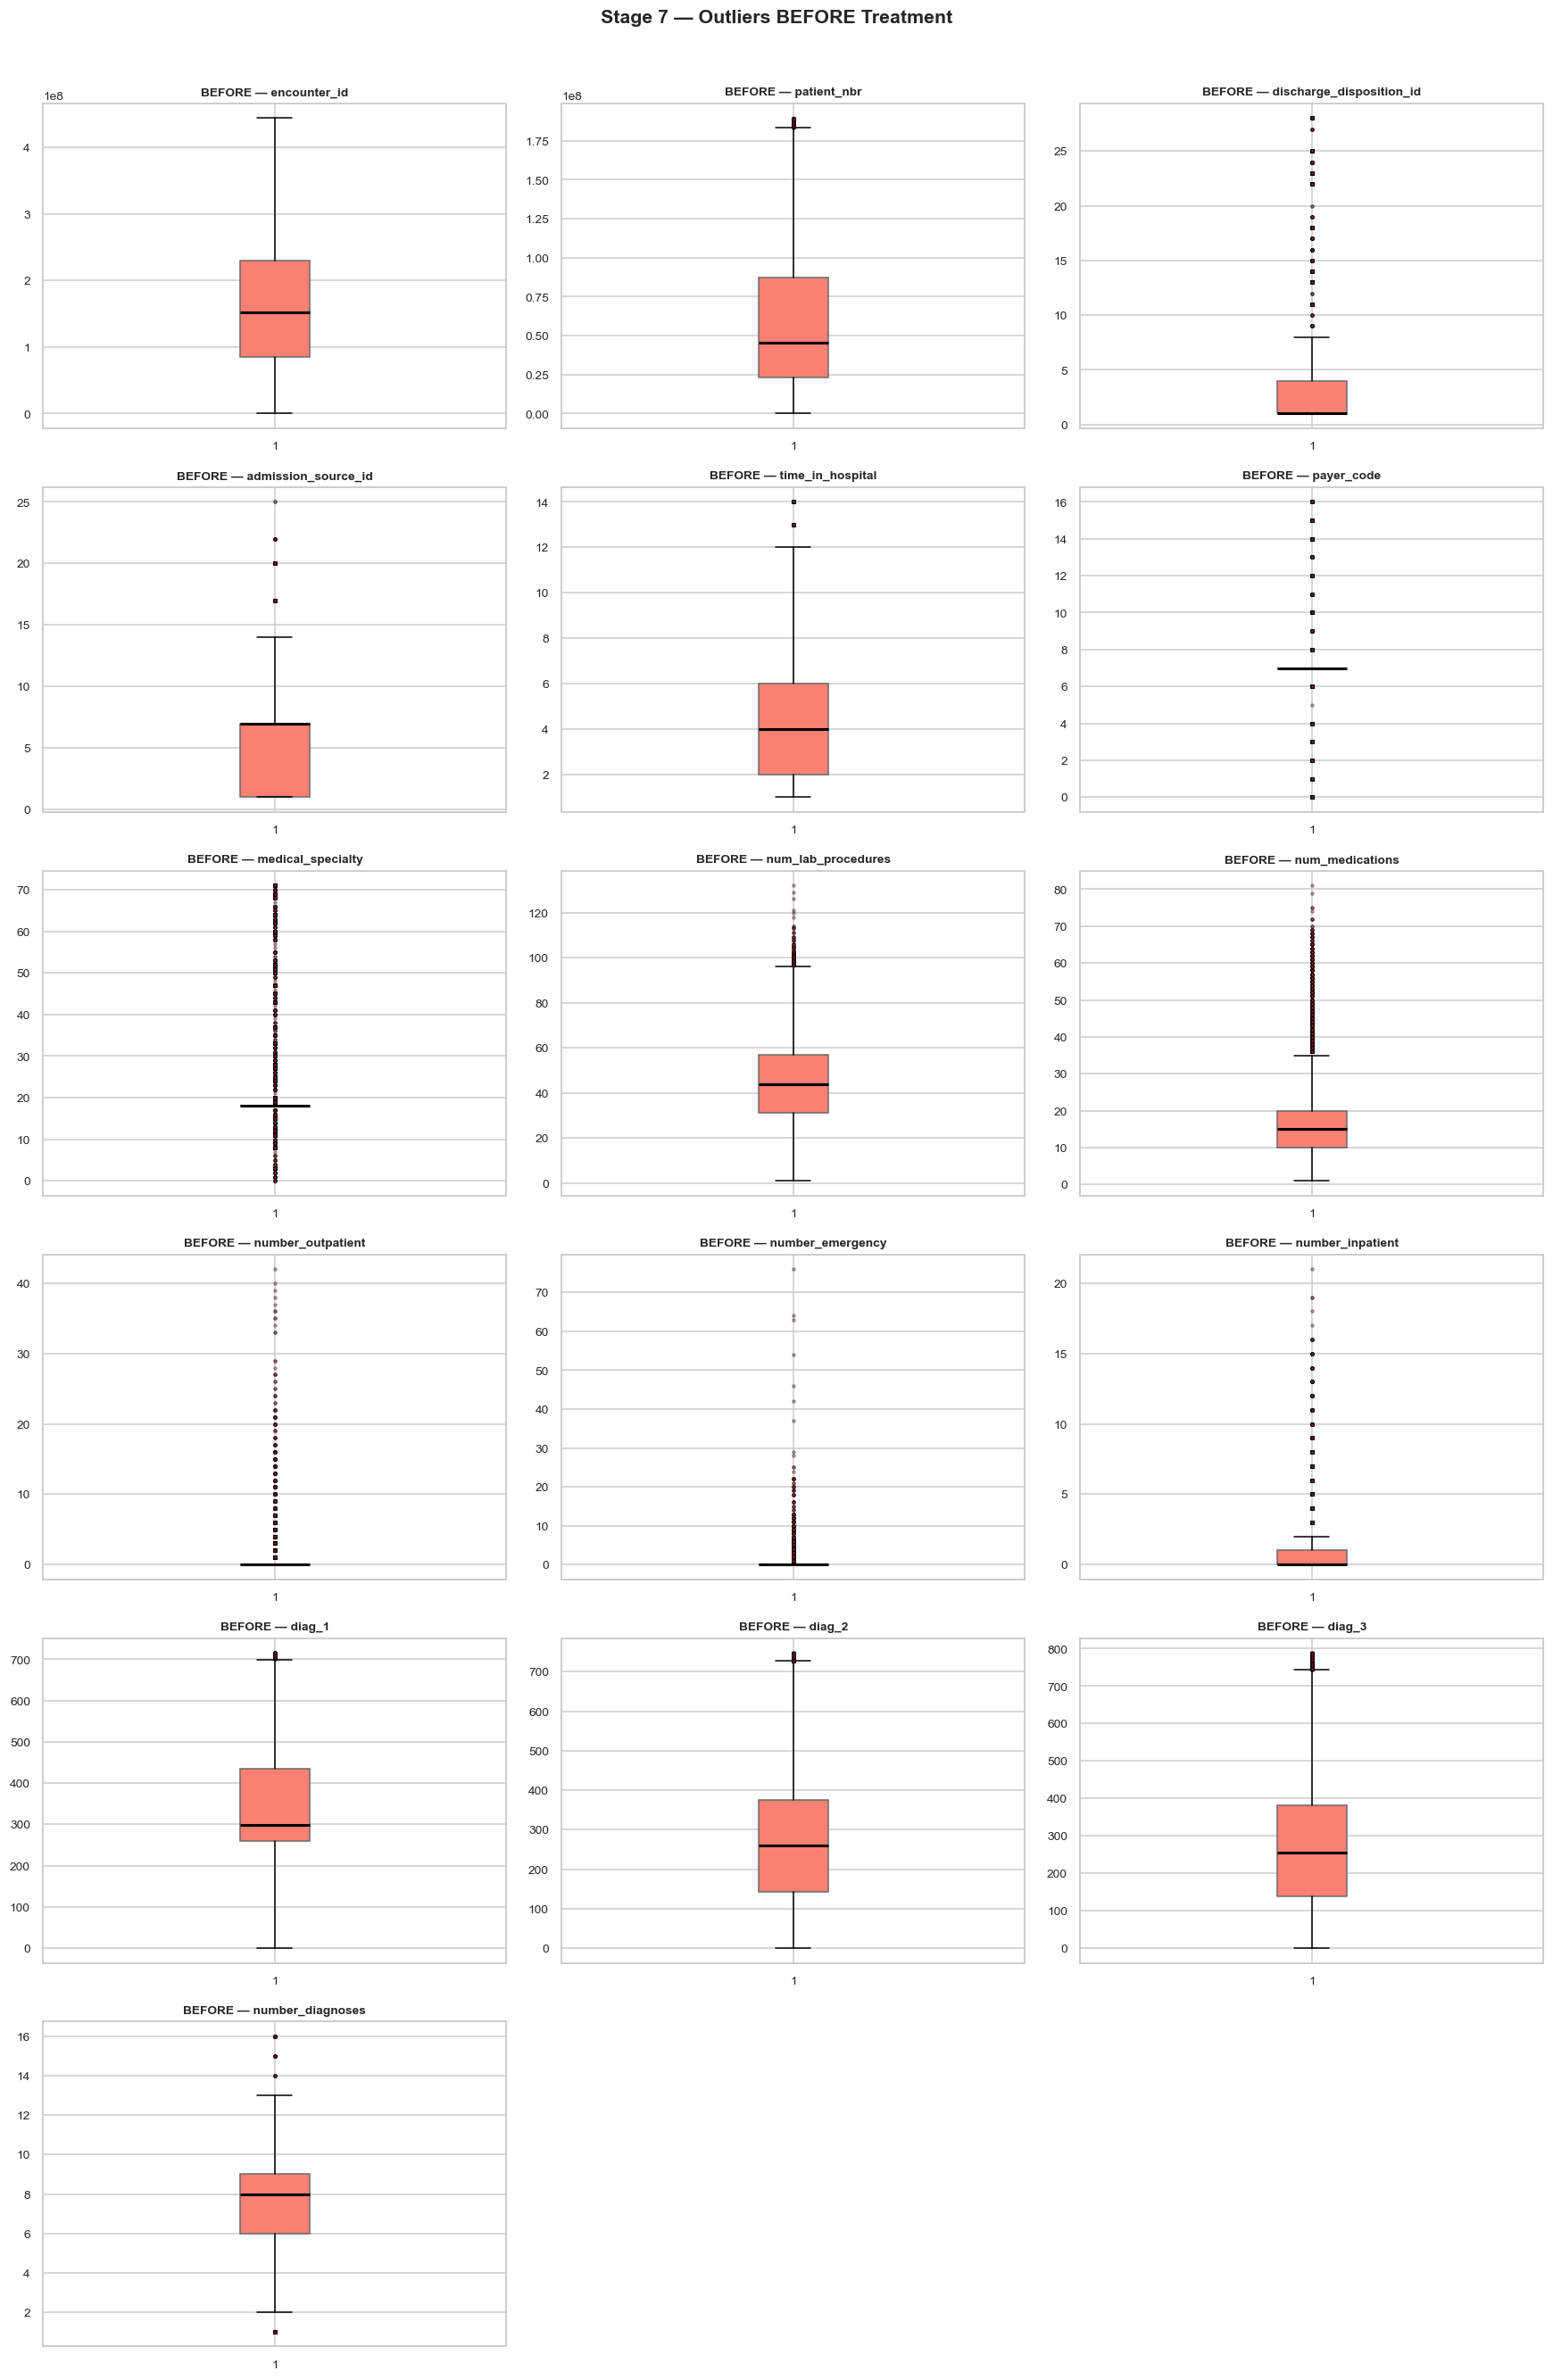

In [240]:
# ── 7.2  BEFORE Treatment — Boxplots ─────────────────────────────────────────
cols_per_row = 3
n    = len(key_numeric)
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="salmon", color="dimgray"),
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.35,
                                    markerfacecolor="crimson"))
    axes[i].set_title(f"BEFORE — {col}", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Stage 7 — Outliers BEFORE Treatment",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [241]:
# ── 7.3  IQR Outlier Report ───────────────────────────────────────────────────
outlier_report = {}
for col in key_numeric:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    n_out   = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        "Q1"           : round(Q1, 2),
        "Q3"           : round(Q3, 2),
        "IQR"          : round(IQR, 2),
        "Lower Fence"  : round(lower, 2),
        "Upper Fence"  : round(upper, 2),
        "Outlier Count": n_out,
        "Outlier (%)"  : round(n_out / len(df) * 100, 2),
    }

outlier_df = pd.DataFrame(outlier_report).T.sort_values("Outlier (%)", ascending=False)
print("IQR Outlier Report (sorted by outlier %):")
print(outlier_df.to_string())


IQR Outlier Report (sorted by outlier %):
                                  Q1            Q3           IQR   Lower Fence   Upper Fence  Outlier Count  Outlier (%)
medical_specialty               18.0  1.800000e+01  0.000000e+00  1.800000e+01  1.800000e+01        37182.0        36.54
payer_code                       7.0  7.000000e+00  0.000000e+00  7.000000e+00  7.000000e+00        29071.0        28.57
number_outpatient                0.0  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00        16739.0        16.45
number_emergency                 0.0  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00        11383.0        11.19
discharge_disposition_id         1.0  4.000000e+00  3.000000e+00 -3.500000e+00  8.500000e+00         9818.0         9.65
number_inpatient                 0.0  1.000000e+00  1.000000e+00 -1.500000e+00  2.500000e+00         7049.0         6.93
admission_source_id              1.0  7.000000e+00  6.000000e+00 -8.000000e+00  1.600000e+01         6956.0    

In [242]:
# ── 7.4  Z-Score Cross-Check ──────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df[key_numeric].dropna()))
z_mask   = (z_scores > 3).any(axis=1)

print(f"Rows flagged by Z-score (|z| > 3) : {z_mask.sum():,}")
print(f"As % of dataset                   : {z_mask.sum() / len(df) * 100:.2f}%")


Rows flagged by Z-score (|z| > 3) : 16,185
As % of dataset                   : 15.90%


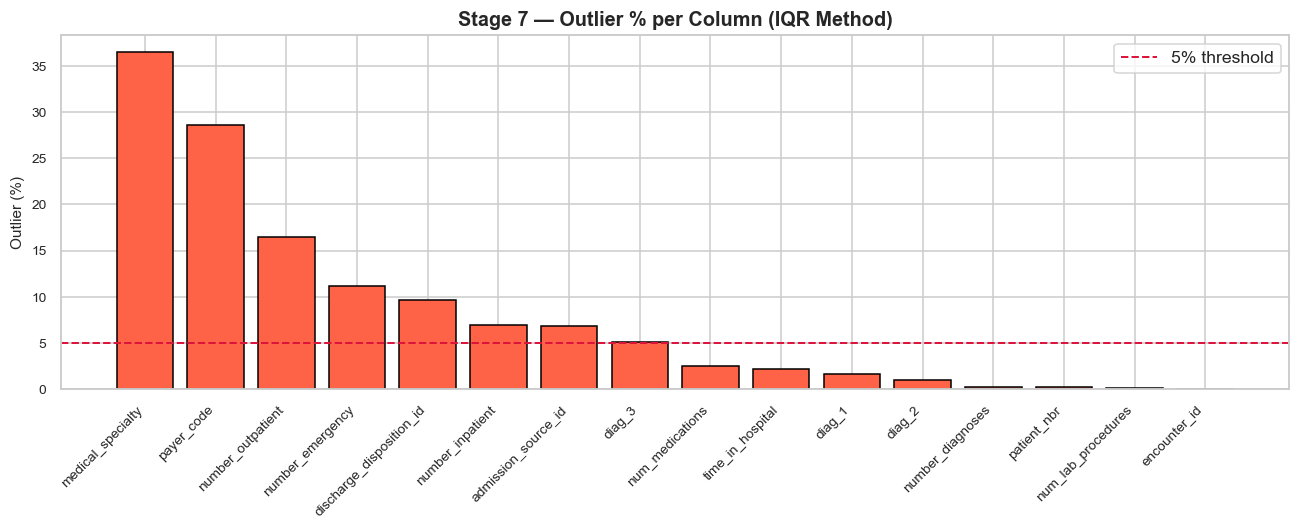

In [243]:
# ── 7.5  Outlier % Bar Chart per Column ──────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.bar(outlier_df.index, outlier_df["Outlier (%)"],
        color="tomato", edgecolor="black")
plt.axhline(5, color="crimson", linestyle="--", linewidth=1.3, label="5% threshold")
plt.title("Stage 7 — Outlier % per Column (IQR Method)",
          fontsize=13, fontweight="bold")
plt.ylabel("Outlier (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


In [244]:
# ── 7.6  Apply Winsorization (clip at 1st–99th percentile) ───────────────────
df_before_cap = df[key_numeric].copy()   # snapshot for before/after comparison

for col in key_numeric:
    p01, p99  = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col]   = df[col].clip(lower=p01, upper=p99)

print("✅ Winsorization complete (clipped at 1st–99th percentile).")
print()
print(f"  {'Column':<35}  {'Before Min':>10}  {'Before Max':>10}  {'After Min':>10}  {'After Max':>10}")
print("  " + "─" * 80)
for col in key_numeric:
    bmin, bmax = df_before_cap[col].min(), df_before_cap[col].max()
    amin, amax = df[col].min(), df[col].max()
    print(f"  {col:<35}  {bmin:>10.1f}  {bmax:>10.1f}  {amin:>10.1f}  {amax:>10.1f}")


✅ Winsorization complete (clipped at 1st–99th percentile).

  Column                               Before Min  Before Max   After Min   After Max
  ────────────────────────────────────────────────────────────────────────────────
  encounter_id                            12522.0  443867222.0   7660291.8  430219329.2
  patient_nbr                               135.0  189502619.0    250204.5  160818198.8
  discharge_disposition_id                    1.0        28.0         1.0        25.0
  admission_source_id                         1.0        25.0         1.0        17.0
  time_in_hospital                            1.0        14.0         1.0        14.0
  payer_code                                  0.0        16.0         0.0        15.0
  medical_specialty                           0.0        71.0         3.0        69.0
  num_lab_procedures                          1.0       132.0         1.0        85.0
  num_medications                             1.0        81.0         3.0      

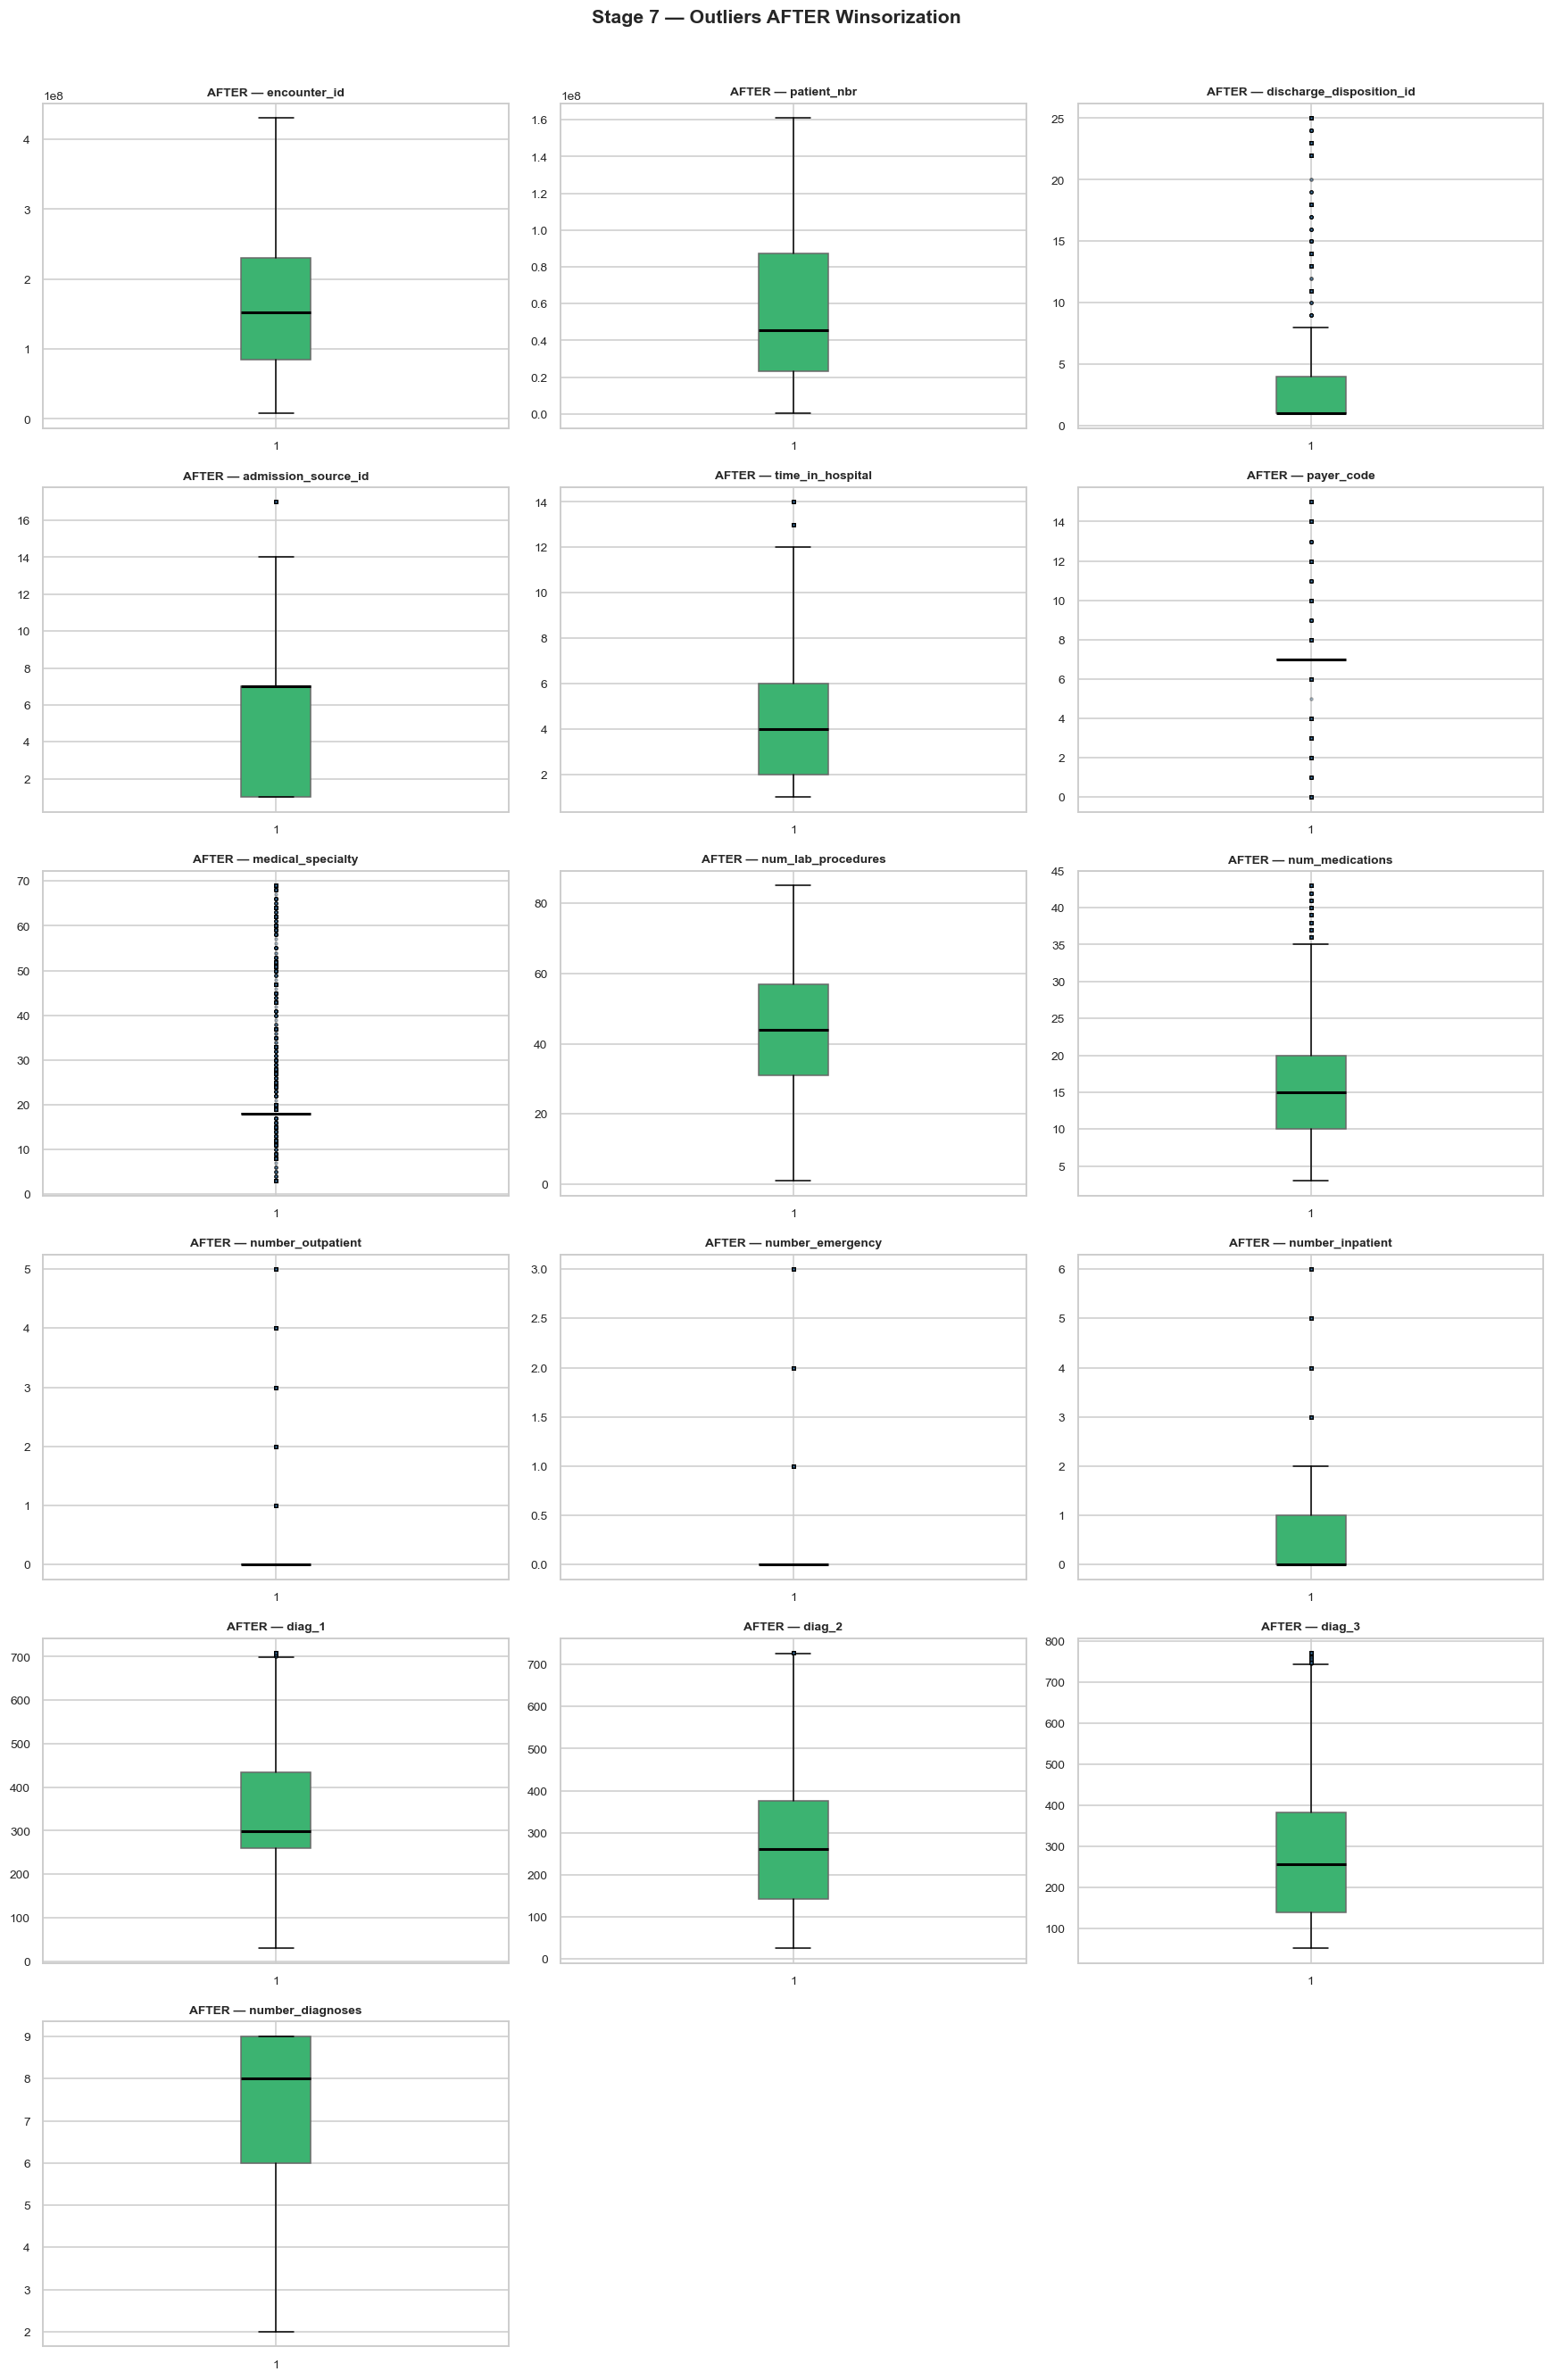

In [245]:
# ── 7.7  AFTER Treatment — Boxplots ──────────────────────────────────────────
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="mediumseagreen", color="dimgray"),
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.3,
                                    markerfacecolor="steelblue"))
    axes[i].set_title(f"AFTER — {col}", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Stage 7 — Outliers AFTER Winsorization",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


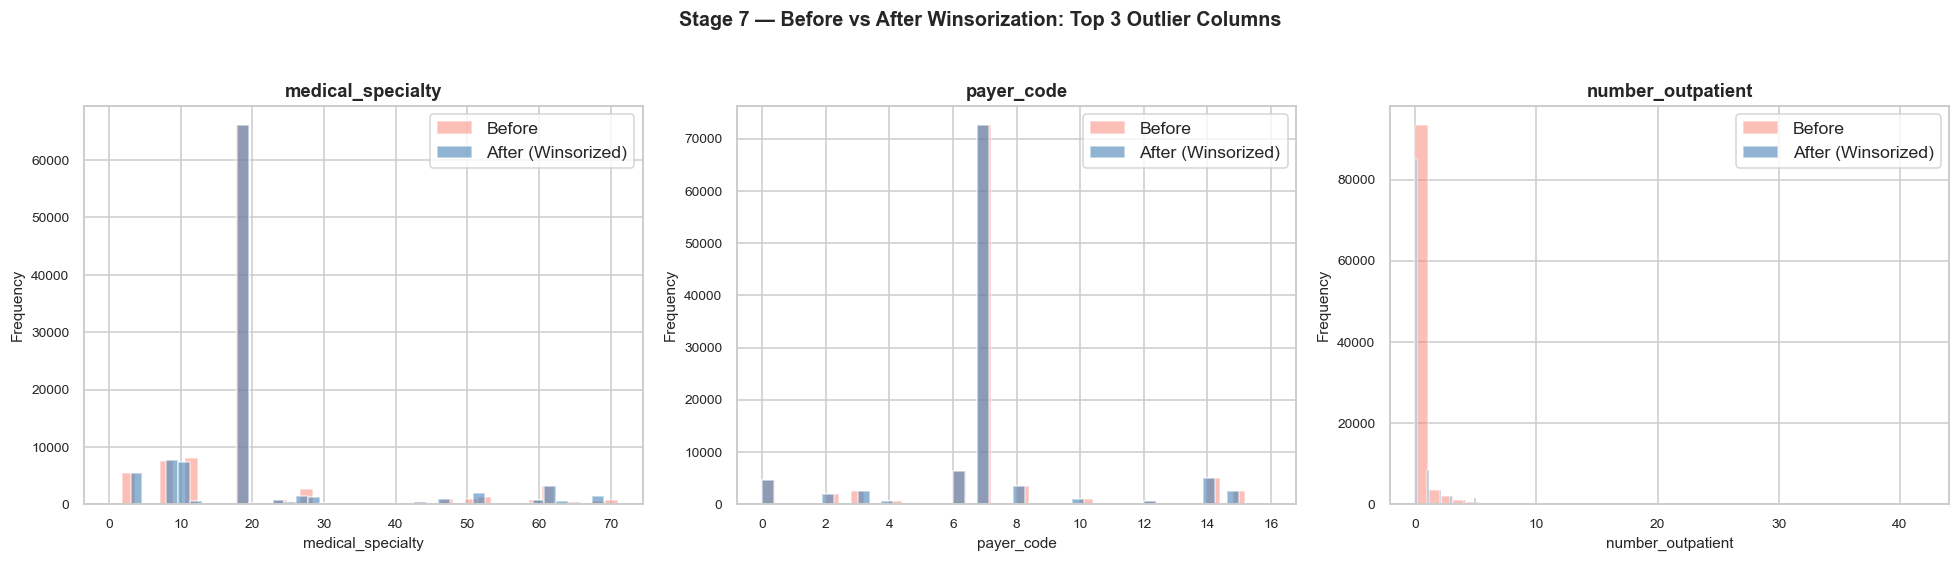

In [246]:
# ── 7.8  Before vs After — Distribution Overlay (Top 3 Outlier Columns) ──────
top3 = outlier_df.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, top3):
    ax.hist(df_before_cap[col].dropna(), bins=40, alpha=0.5,
            color="salmon", label="Before", edgecolor="white")
    ax.hist(df[col].dropna(), bins=40, alpha=0.6,
            color="steelblue", label="After (Winsorized)", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Stage 7 — Before vs After Winsorization: Top 3 Outlier Columns",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 🛠️ Stage 8 — Feature Engineering & Insights
> Create new meaningful features, correct skewness with log transforms, and document key analytical insights for model building.


In [247]:
# ── 8.1  Skewness Check — BEFORE Engineering ─────────────────────────────────
skew_before = df[key_numeric].skew().sort_values(ascending=False)
print("Skewness — BEFORE feature engineering:")
print(skew_before.round(3).to_string())


Skewness — BEFORE feature engineering:
number_emergency            3.707
number_outpatient           3.365
discharge_disposition_id    2.547
number_inpatient            2.481
medical_specialty           2.228
time_in_hospital            1.134
diag_3                      1.049
admission_source_id         1.006
num_medications             0.970
diag_2                      0.750
encounter_id                0.693
payer_code                  0.466
diag_1                      0.384
patient_nbr                 0.376
num_lab_procedures         -0.288
number_diagnoses           -0.920


Highly skewed columns (|skew| > 1): ['number_emergency', 'number_outpatient', 'discharge_disposition_id', 'number_inpatient', 'medical_specialty', 'time_in_hospital', 'diag_3', 'admission_source_id']


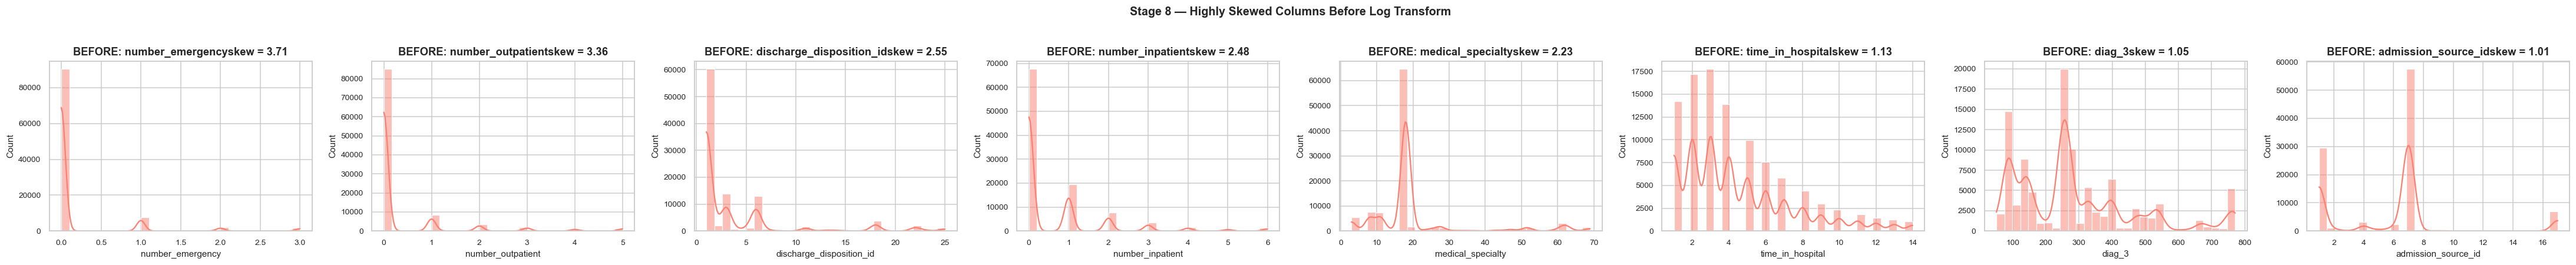

In [248]:
# ── 8.2  Visualise Highly Skewed Columns ─────────────────────────────────────
highly_skewed = skew_before[skew_before.abs() > 1].index.tolist()
print(f"Highly skewed columns (|skew| > 1): {highly_skewed}")

if highly_skewed:
    n_sk  = len(highly_skewed)
    fig, axes = plt.subplots(1, n_sk, figsize=(5 * n_sk, 4))
    if n_sk == 1:
        axes = [axes]
    for ax, col in zip(axes, highly_skewed):
        sns.histplot(df[col], kde=True, ax=ax, color="salmon", bins=30)
        ax.set_title(f"BEFORE: {col}skew = {skew_before[col]:.2f}")
    plt.suptitle("Stage 8 — Highly Skewed Columns Before Log Transform",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


In [249]:
# ── 8.3  Apply Log1p Transform to Reduce Skewness ────────────────────────────
for col in highly_skewed:
    if (df[col] >= 0).all():   # log1p requires non-negative input
        df[f"{col}_log"] = np.log1p(df[col])
        print(f"  ✅  {col}_log   |  skew: {df[col].skew():.2f}  →  {df[f'{col}_log'].skew():.2f}")


  ✅  number_emergency_log   |  skew: 3.71  →  2.97
  ✅  number_outpatient_log   |  skew: 3.36  →  2.44
  ✅  discharge_disposition_id_log   |  skew: 2.55  →  1.31
  ✅  number_inpatient_log   |  skew: 2.48  →  1.35
  ✅  medical_specialty_log   |  skew: 2.23  →  -0.29
  ✅  time_in_hospital_log   |  skew: 1.13  →  0.10
  ✅  diag_3_log   |  skew: 1.05  →  -0.21
  ✅  admission_source_id_log   |  skew: 1.01  →  -0.46


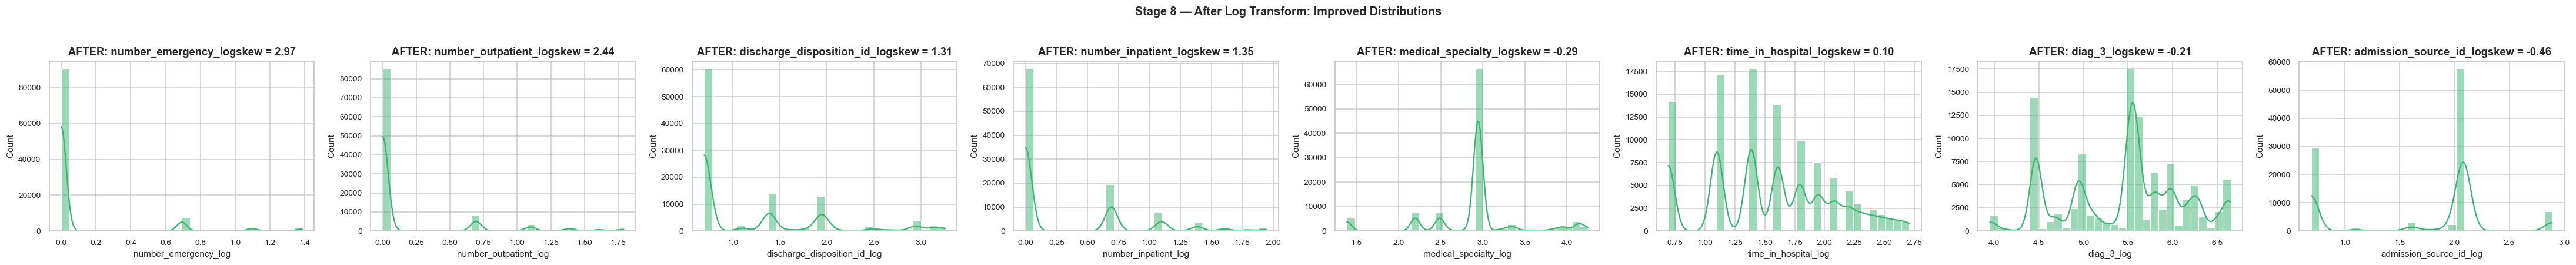

In [250]:
# ── 8.4  Post-Transform Distributions ────────────────────────────────────────
log_cols = [c for c in df.columns if c.endswith("_log")]

if log_cols:
    fig, axes = plt.subplots(1, len(log_cols), figsize=(5 * len(log_cols), 4))
    if len(log_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, log_cols):
        sns.histplot(df[col], kde=True, ax=ax, color="mediumseagreen", bins=30)
        ax.set_title(f"AFTER: {col}skew = {df[col].skew():.2f}")
    plt.suptitle("Stage 8 — After Log Transform: Improved Distributions",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


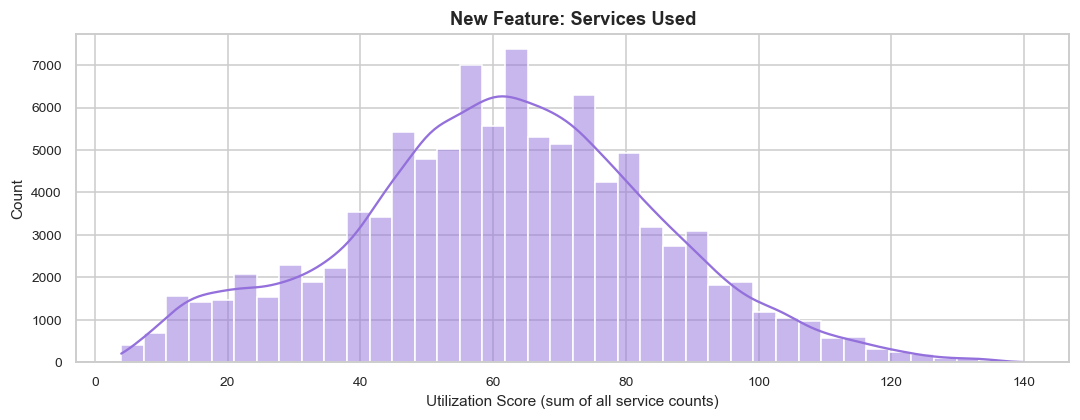

  Skewness: 0.001


In [251]:
# ── 8.5  New Feature: Total Service Utilization ───────────────────────────────
# Aggregates multiple service-count columns into a single patient 'burden' score.
service_cols = [c for c in ["num_lab_procedures","num_procedures","num_medications",
                             "number_outpatient","number_emergency","number_inpatient"]
                if c in df.columns]

df["Services_used"] = df[service_cols].sum(axis=1)

plt.figure(figsize=(10, 4))
sns.histplot(df["Services_used"], kde=True,
             color="mediumpurple", bins=40)
plt.title("New Feature: Services Used",
          fontsize=12, fontweight="bold")
plt.xlabel("Utilization Score (sum of all service counts)")
plt.tight_layout()
plt.show()

print(f"  Skewness: {df['Services_used'].skew():.3f}")


In [252]:
# ── 8.6  New Feature: Medication Change Flag ──────────────────────────────────
# 'change' column indicates whether medication was altered during the visit.
# Already encoded as 0/1 — aliased for semantic clarity.
if "change" in df.columns:
    df["med_changed"] = df["change"]
    print("'med_changed' feature created.")
    print(df["med_changed"].value_counts().rename({0:"No Change", 1:"Changed"}).to_string())


'med_changed' feature created.
med_changed
Changed      54755
No Change    47011


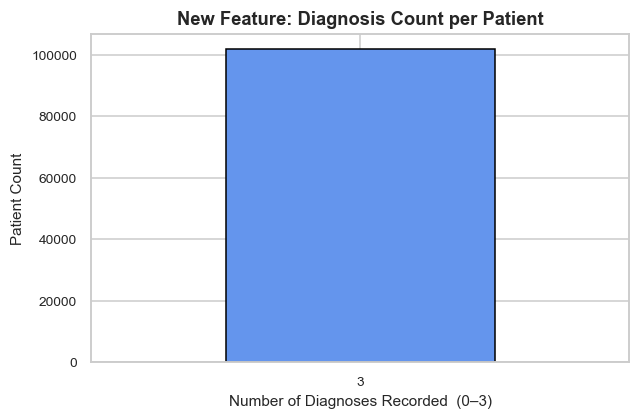

In [253]:
# ── 8.7  New Feature: Diagnosis Count ────────────────────────────────────────
# Counts how many of the 3 diagnosis slots are filled (non-zero after encoding).
diag_cols_present = [c for c in ["diag_1","diag_2","diag_3"] if c in df.columns]
df["diagnosis_count"] = (df[diag_cols_present] != 0).sum(axis=1)

plt.figure(figsize=(6, 4))
df["diagnosis_count"].value_counts().sort_index().plot(
    kind="bar", color="cornflowerblue", edgecolor="black")
plt.title("New Feature: Diagnosis Count per Patient",
          fontsize=12, fontweight="bold")
plt.xlabel("Number of Diagnoses Recorded  (0–3)")
plt.ylabel("Patient Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


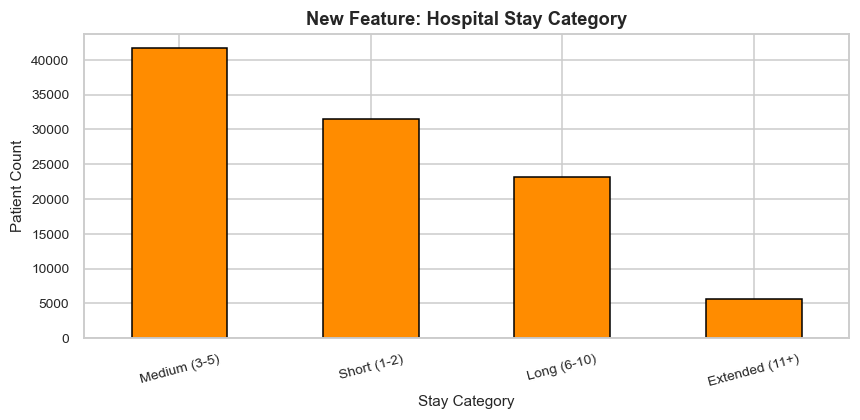

'stay_category' encoded → {'Short (1-2)': 0, 'Medium (3-5)': 1, 'Long (6-10)': 2, 'Extended (11+)': 3}


In [254]:
# ── 8.8  New Feature: Hospital Stay Category (Binned) ────────────────────────
if "time_in_hospital" in df.columns:
    df["stay_category"] = pd.cut(
        df["time_in_hospital"],
        bins=[0, 2, 5, 10, 14],
        labels=["Short (1-2)", "Medium (3-5)", "Long (6-10)", "Extended (11+)"]
    )

    plt.figure(figsize=(8, 4))
    df["stay_category"].value_counts().plot(
        kind="bar", color="darkorange", edgecolor="black")
    plt.title("New Feature: Hospital Stay Category",
              fontsize=12, fontweight="bold")
    plt.xlabel("Stay Category")
    plt.ylabel("Patient Count")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Encode to numeric — required for VarianceThreshold and sklearn models
    stay_map = {"Short (1-2)": 0, "Medium (3-5)": 1,
                "Long (6-10)": 2, "Extended (11+)": 3}
    df["stay_category"] = df["stay_category"].map(stay_map).astype(float)
    print("'stay_category' encoded →", stay_map)


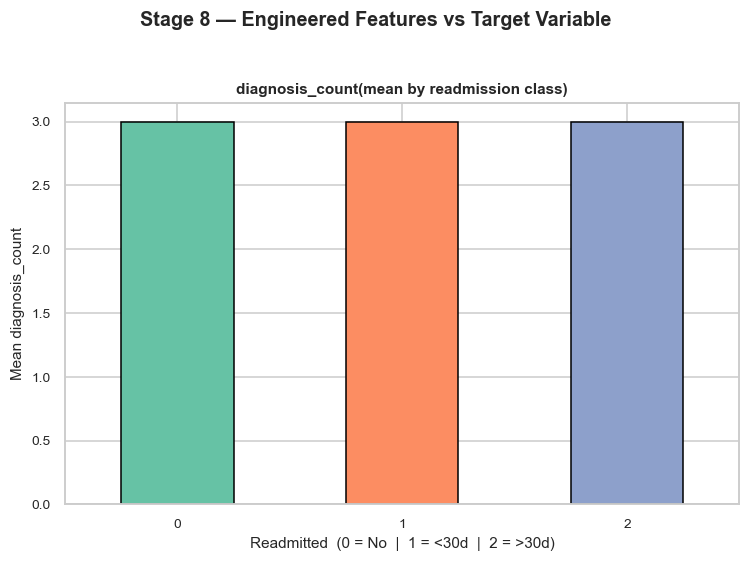

In [255]:
# ── 8.9  Engineered Features vs Target Variable ───────────────────────────────
eng_features = [f for f in ["total_service_utilization","diagnosis_count"]
                if f in df.columns]

fig, axes = plt.subplots(1, len(eng_features), figsize=(7 * len(eng_features), 5))
if len(eng_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, eng_features):
    df.groupby("readmitted")[feat].mean().plot(
        kind="bar", ax=ax,
        color=["#66c2a5","#fc8d62","#8da0cb"], edgecolor="black")
    ax.set_title(f"{feat}(mean by readmission class)", fontsize=10)
    ax.set_xlabel("Readmitted  (0 = No  |  1 = <30d  |  2 = >30d)")
    ax.set_ylabel(f"Mean {feat}")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Stage 8 — Engineered Features vs Target Variable",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [256]:
# ── 8.10  Skewness Comparison — Before vs After ───────────────────────────────
skew_after = df[key_numeric].skew().sort_values(ascending=False)

skew_cmp = pd.DataFrame({
    "Skew Before"            : skew_before,
    "Skew After (Winsorized)": skew_after,
}).round(3)

print("Skewness — Before vs After Winsorization:")
print(skew_cmp.to_string())


Skewness — Before vs After Winsorization:
                          Skew Before  Skew After (Winsorized)
number_emergency                3.707                    3.707
number_outpatient               3.365                    3.365
discharge_disposition_id        2.547                    2.547
number_inpatient                2.481                    2.481
medical_specialty               2.228                    2.228
time_in_hospital                1.134                    1.134
diag_3                          1.049                    1.049
admission_source_id             1.006                    1.006
num_medications                 0.970                    0.970
diag_2                          0.750                    0.750
encounter_id                    0.693                    0.693
payer_code                      0.466                    0.466
diag_1                          0.384                    0.384
patient_nbr                     0.376                    0.376
num_lab_proce

In [257]:
df_final = df.copy()

---
## 🎯 Feature Selection & Final Dataset
> Remove near-zero variance features, inspect final feature distributions, and save the EDA-ready dataset.


In [258]:
# ── Feature Selection: Variance Threshold ─────────────────────────────────────
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

# Guard: keep only numeric columns (prevents string → float errors)
X = X.select_dtypes(include=["int64","float64"])

n_before  = X.shape[1]
selector  = VarianceThreshold(threshold=0.01)
X_var     = selector.fit_transform(X)
sel_cols  = X.columns[selector.get_support()]
X         = X[sel_cols]

print(f"✅ Variance Threshold applied (threshold = 0.01).")
print(f"   Features before : {n_before}")
print(f"   Features after  : {X.shape[1]}")
print(f"   Removed         : {n_before - X.shape[1]}")


✅ Variance Threshold applied (threshold = 0.01).
   Features before : 58
   Features after  : 42
   Removed         : 16


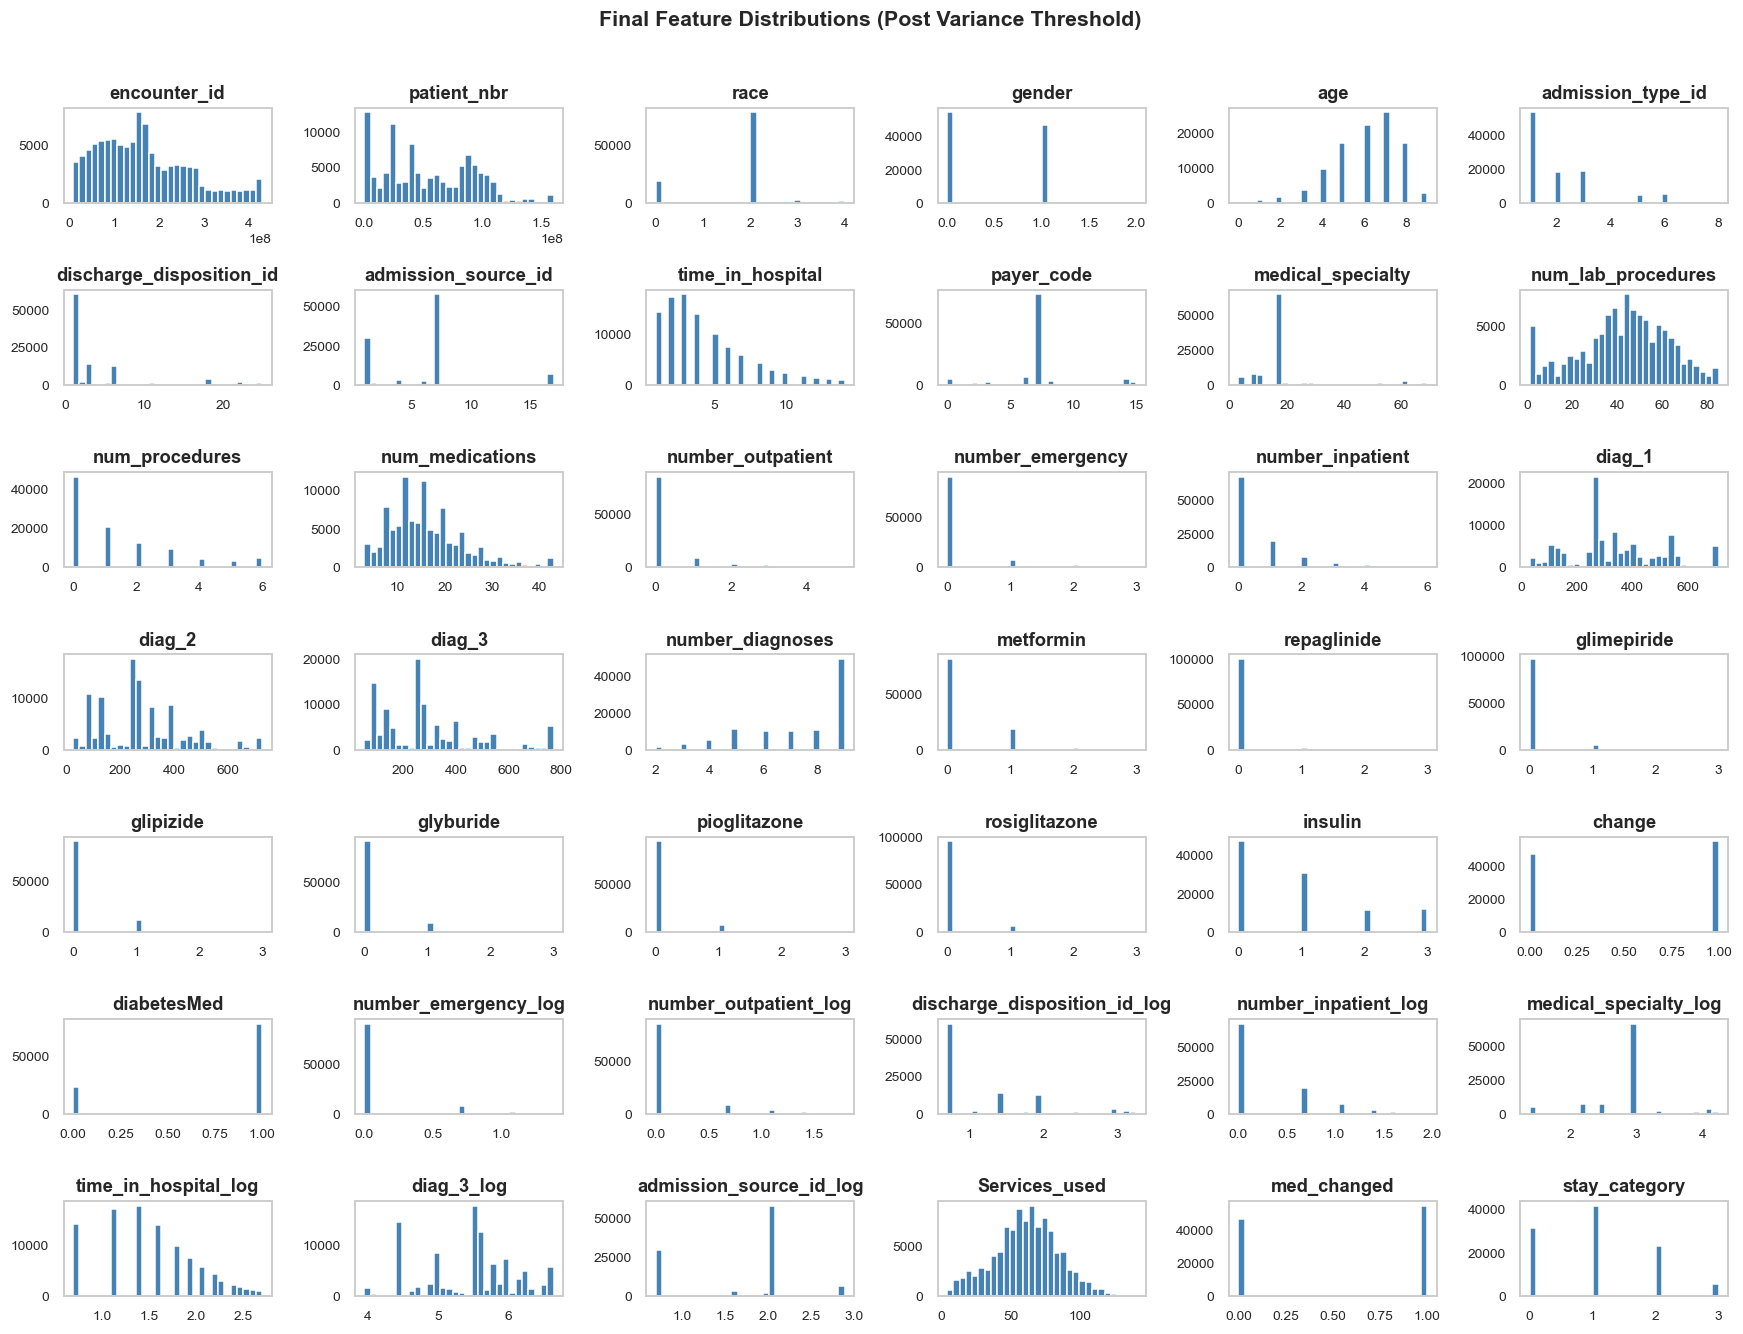

In [259]:
# ── Final Feature Distributions ───────────────────────────────────────────────
X.hist(figsize=(16, 12), bins=30, color="steelblue",
       edgecolor="white", grid=False)
plt.suptitle("Final Feature Distributions (Post Variance Threshold)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [260]:
# ── Final Skewness of Selected Features ──────────────────────────────────────
print("Skewness of selected features (post variance threshold):")
print(X.skew().sort_values(ascending=False).round(3).to_string())


Skewness of selected features (post variance threshold):
repaglinide                     10.410
glimepiride                      5.644
rosiglitazone                    4.445
pioglitazone                     4.187
glyburide                        3.903
number_emergency                 3.707
glipizide                        3.460
number_outpatient                3.365
number_emergency_log             2.971
discharge_disposition_id         2.547
number_inpatient                 2.481
number_outpatient_log            2.435
metformin                        2.417
medical_specialty                2.228
admission_type_id                1.592
number_inpatient_log             1.346
num_procedures                   1.316
discharge_disposition_id_log     1.315
time_in_hospital                 1.134
diag_3                           1.049
admission_source_id              1.006
num_medications                  0.970
insulin                          0.905
diag_2                           0.750
encount

In [261]:
# ── Final Dataset Summary ─────────────────────────────────────────────────────
print(f"Final df shape     : {df.shape}")
print(f"Feature matrix (X) : {X.shape}")
print(f"Target vector  (y) : {y.shape}")
print()
print("Class distribution:")
vc = y.value_counts().sort_index()
for cls, cnt in vc.items():
    label = {0:"No Readmission", 1:"< 30 Days", 2:"> 30 Days"}.get(cls, cls)
    print(f"  Class {cls}  ({label:>15}):  {cnt:>7,}  ({cnt/len(y)*100:.1f}%)")


Final df shape     : (101766, 59)
Feature matrix (X) : (101766, 42)
Target vector  (y) : (101766,)

Class distribution:
  Class 0  ( No Readmission):   11,357  (11.2%)
  Class 1  (      < 30 Days):   35,545  (34.9%)
  Class 2  (      > 30 Days):   54,864  (53.9%)


In [262]:
# ── 8.11 Feature Selection (Reduction) ─────────────────────────────────

print("🔻 Feature Reduction Started...\n")

# Drop weak / useless features
drop_cols = [
    "diagnosis_count",          # constant feature
    "diag_3_log",               # no variation
    "medical_specialty_log"     # wrong transformation (categorical)
]

# Drop only if they exist
drop_cols = [col for col in drop_cols if col in df.columns]

df.drop(columns=drop_cols, inplace=True)

print("Dropped Features:")
for col in drop_cols:
    print(f"  ❌ {col}")

print(f"\nRemaining Features: {df.shape[1]}")

🔻 Feature Reduction Started...

Dropped Features:
  ❌ diagnosis_count
  ❌ diag_3_log
  ❌ medical_specialty_log

Remaining Features: 56


In [263]:
# ── Save EDA-Ready Dataset ────────────────────────────────────────────────────
df.to_csv("EDA_Complete_dataset.csv", index=False)
print("✅ Saved: EDA_Complete_dataset.csv")
print(f"   Shape : {df.shape}")


✅ Saved: EDA_Complete_dataset.csv
   Shape : (101766, 56)


📊 FULL PIPELINE COMPARISON

Shape Comparison:
RAW   : (101766, 50)
CLEAN : (101766, 47)
FINAL : (101766, 59)

Missing Values:
RAW   : 181168
CLEAN : 0
FINAL : 0
Missing Reduction (RAW → CLEAN): 100.00%

Skewness Comparison (Top 10):
                             RAW   CLEAN  FINAL
number_emergency          22.856  22.856  3.707
number_outpatient          8.833   8.833  3.365
number_inpatient           3.614   3.614  2.481
discharge_disposition_id   2.563   2.563  2.547
admission_type_id          1.592   1.592  1.592
num_medications            1.327   1.327  0.970
num_procedures             1.316   1.316  1.316
time_in_hospital           1.134   1.134  1.134
admission_source_id        1.030   1.030  1.006
encounter_id               0.699   0.699  0.693 

Average Skewness Improvement: 2.012

Variance Comparison (Top 5):
                                   RAW         CLEAN         FINAL
encounter_id              1.053503e+16  1.053503e+16  1.048761e+16
patient_nbr               1.497408e+1

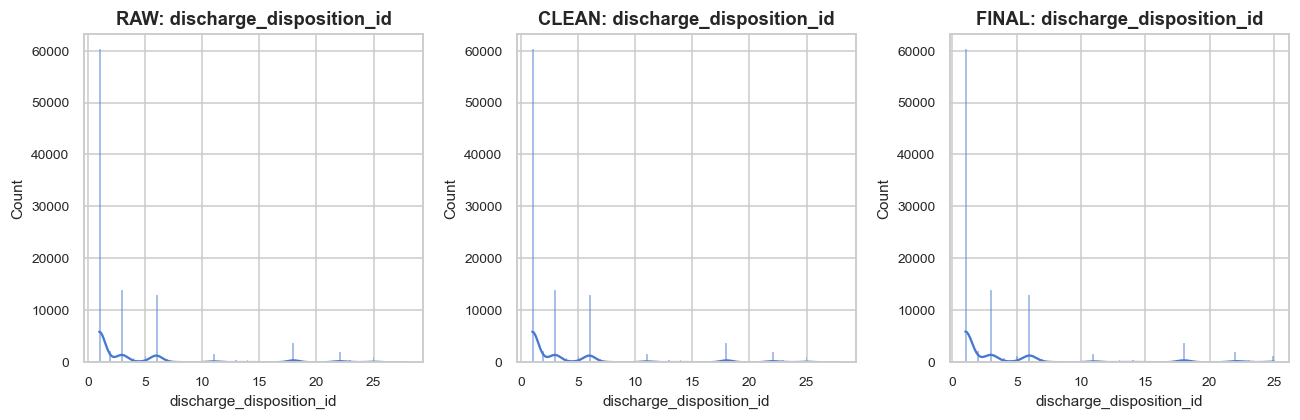

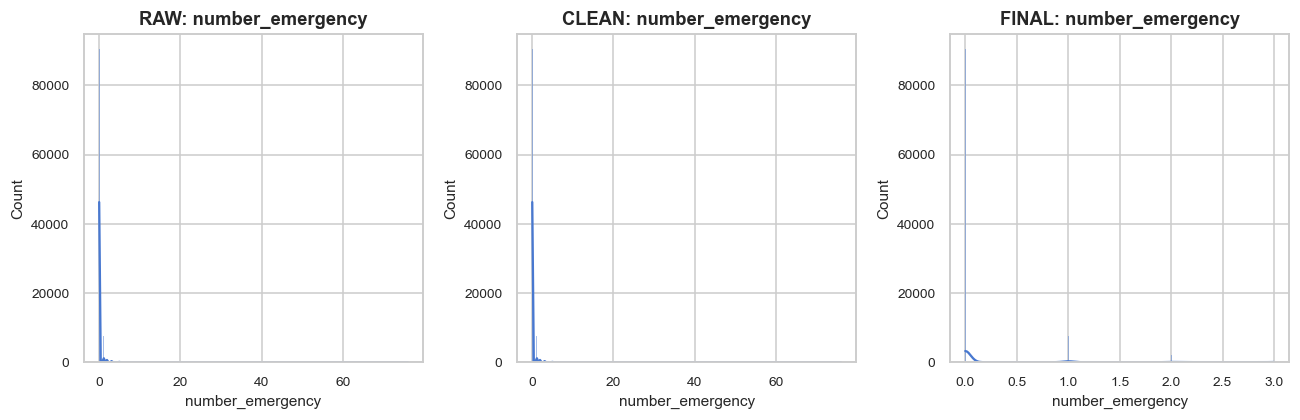

Feature Count:
RAW   : 50
CLEAN : 47
FINAL : 59

New Features Created:
  + discharge_disposition_id_log
  + stay_category
  + number_outpatient_log
  + diagnosis_count
  + diag_3_log
  + admission_source_id_log
  + medical_specialty_log
  + time_in_hospital_log
  + number_emergency_log
  + med_changed
  + number_inpatient_log
  + Services_used

Total New Features: 12

Feature vs Target (Final Data):

discharge_disposition_id_log:
readmitted
0    1.32
1    1.16
2    1.20
Name: discharge_disposition_id_log, dtype: float64

stay_category:
readmitted
0    1.14
1    1.06
2    0.99
Name: stay_category, dtype: float64

number_outpatient_log:
readmitted
0    0.20
1    0.22
2    0.13
Name: number_outpatient_log, dtype: float64

diagnosis_count:
readmitted
0    3.0
1    3.0
2    3.0
Name: diagnosis_count, dtype: float64

diag_3_log:
readmitted
0    5.47
1    5.48
2    5.45
Name: diag_3_log, dtype: float64

Top Correlated Features with Target:

number_inpatient     0.239613
number_emergency     0

In [264]:
# ── Stage 9 — Raw vs Clean vs Final Comparison ──────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 FULL PIPELINE COMPARISON\n")

# ── 9.1 Shape Comparison ────────────────────────────────────────────────
print("Shape Comparison:")
print(f"RAW   : {df_raw.shape}")
print(f"CLEAN : {df_clean.shape}")
print(f"FINAL : {df_final.shape}\n")


# ── 9.2 Missing Values ──────────────────────────────────────────────────
raw_missing   = df_raw.isnull().sum().sum()
clean_missing = df_clean.isnull().sum().sum()
final_missing = df_final.isnull().sum().sum()

print("Missing Values:")
print(f"RAW   : {raw_missing}")
print(f"CLEAN : {clean_missing}")
print(f"FINAL : {final_missing}")

if raw_missing > 0:
    reduction = ((raw_missing - clean_missing) / raw_missing) * 100
    print(f"Missing Reduction (RAW → CLEAN): {reduction:.2f}%\n")
else:
    print()


# ── 9.3 Common Numeric Columns (SAFE) ───────────────────────────────────
common_cols = list(
    set(df_raw.columns) & set(df_clean.columns) & set(df_final.columns)
)

num_cols = [
    col for col in common_cols
    if pd.api.types.is_numeric_dtype(df_clean[col]) and
       pd.api.types.is_numeric_dtype(df_raw[col]) and
       pd.api.types.is_numeric_dtype(df_final[col])
]


# ── 9.4 Skewness Comparison ─────────────────────────────────────────────
skew_df = pd.DataFrame({
    "RAW": df_raw[num_cols].skew(),
    "CLEAN": df_clean[num_cols].skew(),
    "FINAL": df_final[num_cols].skew()
}).dropna()

print("Skewness Comparison (Top 10):")
print(skew_df.sort_values(by="RAW", ascending=False).head(10).round(3), "\n")

# Skewness improvement score
skew_improvement = (skew_df["RAW"].abs() - skew_df["FINAL"].abs()).mean()
print(f"Average Skewness Improvement: {skew_improvement:.3f}\n")


# ── 9.5 Variance Comparison (NEW — ADVANCED) ─────────────────────────────
print("Variance Comparison (Top 5):")
var_df = pd.DataFrame({
    "RAW": df_raw[num_cols].var(),
    "CLEAN": df_clean[num_cols].var(),
    "FINAL": df_final[num_cols].var()
}).dropna()

print(var_df.sort_values(by="RAW", ascending=False).head(5).round(2), "\n")


# ── 9.6 Distribution Comparison ─────────────────────────────────────────
sample_cols = list(num_cols[:2]) if len(num_cols) > 0 else []

for col in sample_cols:
    plt.figure(figsize=(12,4))
    
    if col in df_raw.columns:
        plt.subplot(1,3,1)
        sns.histplot(df_raw[col], kde=True)
        plt.title(f"RAW: {col}")
    
    if col in df_clean.columns:
        plt.subplot(1,3,2)
        sns.histplot(df_clean[col], kde=True)
        plt.title(f"CLEAN: {col}")
    
    if col in df_final.columns:
        plt.subplot(1,3,3)
        sns.histplot(df_final[col], kde=True)
        plt.title(f"FINAL: {col}")
    
    plt.tight_layout()
    plt.show()


# ── 9.7 Feature Growth ──────────────────────────────────────────────────
print("Feature Count:")
print(f"RAW   : {df_raw.shape[1]}")
print(f"CLEAN : {df_clean.shape[1]}")
print(f"FINAL : {df_final.shape[1]}\n")

new_features = list(set(df_final.columns) - set(df_clean.columns))

print("New Features Created:")
for f in new_features:
    print(f"  + {f}")

print(f"\nTotal New Features: {len(new_features)}\n")


# ── 9.8 Feature vs Target (Final Data) ──────────────────────────────────
if "readmitted" in df_final.columns:
    print("Feature vs Target (Final Data):\n")
    
    for col in new_features[:5]:
        if col in df_final.select_dtypes(include=np.number).columns:
            print(f"{col}:")
            print(df_final.groupby("readmitted")[col].mean().round(2))
            print()


# ── 9.9 Correlation with Target (NEW — VERY STRONG) ─────────────────────
if "readmitted" in df_final.columns and len(num_cols) > 0:
    print("Top Correlated Features with Target:\n")
    
    corr = df_final[num_cols].corrwith(df_final["readmitted"]).abs().sort_values(ascending=False)
    print(corr.head(5), "\n")


# ── 9.10 Final Summary ──────────────────────────────────────────────────
print("✅ PIPELINE SUMMARY:")
print("- RAW → CLEAN: Missing values handled, encoding applied")
print("- CLEAN → FINAL: Feature engineering + skewness reduction")
print("- Skewness reduced and variance stabilized")
print("- Feature space expanded with meaningful signals")
print("- FINAL dataset is optimized for ML models")